<div style="font-size: 30px; font-weight: 700; margin-bottom: 0.4em;">MBTI Personality Type Classification</div>

# Project Overview

This notebook studies MBTI personality type prediction from user-level text. MBTI is represented as four binary axes: `EI`, `NS`, `TF`, and `JP`. A complete MBTI type is recovered by combining the four axis predictions.

The project compares three modelling families:

- Classical multilabel methods from the course: Binary Relevance, Classifier Chains, and Label Powerset.
- Shared-encoder transformer models with one encoder and four MBTI axis heads.
- Zero-shot transfer from MBTI-trained models to Pandora Big Five/OCEAN traits.

The main MBTI benchmark is the Kaggle MBTI dataset with stratified user-level train/validation/test splits. Pandora is not used as MBTI-labelled test data; it is used only to check whether MBTI-trained model scores correlate with related OCEAN personality traits.

## Notebook Map

- Section 0: imports, paths, seeds, device setup, and reproducibility settings.
- Section 1: Kaggle MBTI loading, text cleaning, label extraction, and user-level splits.
- Section 3: classical multilabel baselines and classical comparison plots.
- Section 4: transformer utilities, shared 4-head transformer training, and final MBTI comparison.
- Section 5: MBTI-to-OCEAN zero-shot transfer analysis on Pandora.

## Caching Strategy

The most expensive steps are cached so the notebook can be rerun incrementally:

- Processed splits: `data/cache_*.parquet`
- Classical models: `results/tfidf_*.joblib`
- Shared transformer checkpoints: `results/multilabel_*_best/`
- Final summaries and plots: `results/*.csv` and `results/*.png`


# 0 - Environment and Reproducibility

This section centralizes imports, file paths, random seeds, hardware settings, and shared constants. Keeping these definitions in one place makes later cells easier to rerun after a kernel restarts.

Important shared constants:

- `LABEL_ORDER`: the four MBTI binary axes used throughout the notebook.
- `AXES`: maps each axis to its positive and negative MBTI letters.
- `RESULTS_DIR`: stores cached models, predictions, metrics, and figures.
- `SEED`: controls train/test splits and model randomness where supported.


In [21]:
import os
import random
import re
import time
import warnings
import json
import gc
from pathlib import Path
from types import SimpleNamespace
from typing import Any, Callable, Literal, cast

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import sklearn.base as sk_base
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import (
    AutoModel,
    AutoTokenizer,
    default_data_collator,
    get_linear_schedule_with_warmup,
)

# - reproducibility -
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# - parallelism: use every available CPU core
N_CORES = os.cpu_count() or 1
os.environ["OMP_NUM_THREADS"]        = str(N_CORES)
os.environ["MKL_NUM_THREADS"]        = str(N_CORES)
os.environ["OPENBLAS_NUM_THREADS"]   = str(N_CORES)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_CORES)
os.environ["NUMEXPR_NUM_THREADS"]    = str(N_CORES)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

torch.set_num_threads(N_CORES)
try:
    torch.set_num_interop_threads(N_CORES)
except RuntimeError:
    pass  # already set by the kernel before this cell ran - safe to ignore

DATALOADER_WORKERS = 0
dataloader_workers = DATALOADER_WORKERS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -- ROCm / CUDA GPU optimizations --------------------------------------------
if torch.cuda.is_available():
    # Reduce memory fragmentation - important for large models on ROCm
    os.environ.setdefault(
        "PYTORCH_HIP_ALLOC_CONF",
        "garbage_collection_threshold:0.8,max_split_size_mb:512"
    )
    os.environ.setdefault(
        "PYTORCH_CUDA_ALLOC_CONF",
        "garbage_collection_threshold:0.8,max_split_size_mb:512"
    )

    # RX 9070 XT = gfx1201 (RDNA 4 / Navi 48).
    # If ROCm doesn't auto-detect the GFX version correctly, this forces it.
    # Safe to set even on newer ROCm versions that already know gfx1201.
    os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "12.0.1")

    # Let MIOpen/cuDNN benchmark and cache the fastest kernel per input shape
    torch.backends.cudnn.benchmark   = True
    # TF32 matmuls on Ampere+ CUDA (ignored on ROCm, no harm)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.set_float32_matmul_precision("high")

    GPU_NAME  = torch.cuda.get_device_name(0)
    GPU_MEM   = torch.cuda.get_device_properties(0).total_memory / 1e9
    GPU_COUNT = torch.cuda.device_count()

    # bf16 is natively faster on RDNA4
    # fp16 is the fallback for older hardware that lacks bf16 hardware.
    USE_BF16 = torch.cuda.is_bf16_supported()
    USE_FP16 = not USE_BF16

    # Effective batch stays 64 via gradient accumulation; increasing per-device
    # batch reduces accumulation steps and speeds up training.
    VRAM_GB = GPU_MEM
    if VRAM_GB >= 14:
        TRAIN_BATCH = 32   # fits RoBERTa/PsychBERT at seq_len=256 on 16 GB
        EVAL_BATCH  = 64
    elif VRAM_GB >= 8:
        TRAIN_BATCH = 16
        EVAL_BATCH  = 32
    else:
        TRAIN_BATCH = 8
        EVAL_BATCH  = 16

    torch.cuda.empty_cache()
    print(f"GPU             : {GPU_NAME}  ({GPU_MEM:.1f} GB VRAM, {GPU_COUNT} device(s))")
    print(f"Precision       : {'bf16' if USE_BF16 else 'fp16'}")
    print(f"Batch sizes     : train={TRAIN_BATCH}  eval={EVAL_BATCH}")
else:
    GPU_NAME    = "CPU"
    GPU_MEM     = 0
    USE_BF16    = False
    USE_FP16    = False
    TRAIN_BATCH = 8
    EVAL_BATCH  = 16
    print("No GPU detected - running on CPU")

print(f"Device          : {str(DEVICE)}")
print(f"CPU cores       : {N_CORES}  (dataloader workers: {DATALOADER_WORKERS})")
print(f"PyTorch         : {torch.__version__}")

warnings.filterwarnings("ignore")

DATA_DIR    = Path("data")
RESULTS_DIR = Path("results")
CKPT_DIR    = Path("checkpoints")
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)

MBTI_TYPES = [
    "INFJ","INFP","INTJ","INTP","ISFJ","ISFP","ISTJ","ISTP",
    "ENFJ","ENFP","ENTJ","ENTP","ESFJ","ESFP","ESTJ","ESTP",
]
MBTI_RE = re.compile(r"\b([IE][NS][TF][JP])\b", re.IGNORECASE)

AXES = {
    "EI": ("E", "I"),
    "NS": ("N", "S"),
    "TF": ("T", "F"),
    "JP": ("J", "P"),
}
LABEL_ORDER = list(AXES.keys())   # ['EI','NS','TF','JP']

GPU             : AMD Radeon RX 9070 XT  (17.1 GB VRAM, 1 device(s))
Precision       : bf16
Batch sizes     : train=32  eval=64
Device          : cuda
CPU cores       : 16  (dataloader workers: 0)
PyTorch         : 2.13.0a0+rocm7.13.0a20260416


# 1 - Data Loading and User-Level Splitting

This section loads the Kaggle MBTI dataset and prepares the main supervised MBTI benchmark.

Key choices:

- The unit of analysis is the user, not an individual post.
- The four MBTI axes are extracted from the 16-type label.
- Text cleaning removes URLs, separators, punctuation noise, and explicit MBTI type words to reduce label leakage.
- The split is stratified by full MBTI type into train, validation, and test sets using a 70/15/15 ratio.

The validation split is used for tuning thresholds and hyperparameters. The test split is used only for final evaluation.


In [22]:
CACHE_TRAIN = DATA_DIR / "cache_train.parquet"
CACHE_VAL   = DATA_DIR / "cache_val.parquet"
CACHE_TEST  = DATA_DIR / "cache_test.parquet"

MBTI_TYPES_LOWER = [t.lower() for t in MBTI_TYPES]

def clean_text_pipeline(text: str, keep_case: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    t = text if keep_case else text.lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\|+", " ", t)  # Automatically converts ||| dividers into clean spaces
    # Remove explicit MBTI type mentions so the model cannot learn the label from leaked text.
    for mbti in MBTI_TYPES_LOWER:
        t = re.sub(rf"\b{mbti}\b", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"[^a-zA-Z\s]" if keep_case else r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

if CACHE_TRAIN.exists() and CACHE_VAL.exists() and CACHE_TEST.exists():
    print(" Loading cached Kaggle user splits...")
    train_df = pd.read_parquet(CACHE_TRAIN)
    val_df   = pd.read_parquet(CACHE_VAL)
    test_df  = pd.read_parquet(CACHE_TEST)
    print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
else:
    print("Processing Kaggle dataset at the User level...")
    raw_kaggle = pd.read_csv(DATA_DIR / "mbti_1.csv")
    raw_kaggle.columns = raw_kaggle.columns.str.strip().str.lower()
    raw_kaggle = raw_kaggle.rename(columns={"type": "mbti_type", "posts": "posts_raw"})
    raw_kaggle["mbti_type"] = raw_kaggle["mbti_type"].str.upper().str.strip()

    # Map binary classification targets
    for axis, (pos, _) in AXES.items():
        raw_kaggle[axis] = raw_kaggle["mbti_type"].str.contains(pos, case=False).astype(int)

    print("Applying text cleaning directly to user text blocks...")
    raw_kaggle["clean_text"] = raw_kaggle["posts_raw"].apply(lambda x: clean_text_pipeline(x, keep_case=False))
    raw_kaggle["clean_text_cased"] = raw_kaggle["posts_raw"].apply(lambda x: clean_text_pipeline(x, keep_case=True))

    # Filter out empty entries
    raw_kaggle = raw_kaggle[raw_kaggle["clean_text"].str.len() >= 50].reset_index(drop=True)

    # Stratify by full MBTI type so rare types are represented in every split.
    print("Executing stratified User-Level Splits (70/15/15)...")
    train_df, temp_df = train_test_split(
        raw_kaggle, test_size=0.30, stratify=raw_kaggle["mbti_type"], random_state=SEED
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["mbti_type"], random_state=SEED
    )

    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

    train_df.to_parquet(CACHE_TRAIN, index=False)
    val_df.to_parquet(CACHE_VAL,     index=False)
    test_df.to_parquet(CACHE_TEST,   index=False)
    print(f" Pure Kaggle User Splits Cached: Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

def df_to_multilabel(df: pd.DataFrame) -> pd.DataFrame:
    return df[LABEL_ORDER].reset_index(drop=True)


 Loading cached Kaggle user splits...
  Train: 6,071 | Val: 1,301 | Test: 1,301


# 2 - Experimental Setup and Evaluation Plan

The supervised MBTI experiments all use the same user-level train, validation, and test splits.

Evaluation is reported at two levels:

- Axis-level evaluation: each MBTI dimension is evaluated as a binary classification task using macro-F1 and ROC-AUC.
- Full-type evaluation: the four axis predictions are combined into a complete MBTI type, allowing exact type accuracy to be reported.

Macro-F1 is preferred over positive-class F1 for model comparison because several axes are imbalanced. Validation data is used for threshold tuning and hyperparameter selection; test data is reserved for final reported results.


# 3 - Classical ML Multilabel Baselines

This section builds strong non-neural baselines and course-relevant multilabel methods before moving to transformers.

The classical suite includes:

- TF-IDF word and character n-grams with Logistic Regression Binary Relevance.
- TF-IDF word and character n-grams with calibrated LinearSVC Binary Relevance.
- TF-IDF classifier-chain ensemble.
- TF-IDF Label Powerset over the 16 MBTI label combinations.

Why these methods matter:

- Binary Relevance tests how well each axis can be learned independently.
- Classifier Chains model dependencies between axes by passing previous predictions into later classifiers.
- Label Powerset treats each full MBTI type as one multiclass label, which directly fits the 16-type structure of MBTI.


## 3.1 - Classical Data Matrices

This cell prepares shared user-level train/validation/test dataframes and label matrices used by the classical models. The sparse TF-IDF models build their own word and character n-gram features later.


In [23]:
# Synchronize dataset formats for classical matrices
user_train = train_df.copy()
user_val = val_df.copy()
user_test = test_df.copy()

# Map aliases to match matrix definitions in the following sections.
user_train["agg_text"] = user_train["clean_text"]
user_val["agg_text"] = user_val["clean_text"]
user_test["agg_text"] = user_test["clean_text"]

print(f"User-level Matrix Shapes - Train: {len(user_train):,} | Val: {len(user_val):,} | Test: {len(user_test):,}")

# Keep labels in the same row order as the feature matrices.
y_train_ml = user_train[LABEL_ORDER].reset_index(drop=True)
y_val_ml = user_val[LABEL_ORDER].reset_index(drop=True)
y_test_ml = user_test[LABEL_ORDER].reset_index(drop=True)


User-level Matrix Shapes - Train: 6,071 | Val: 1,301 | Test: 1,301


## 3.2 - Classifier-Chain Utility Functions

These helper functions train multiple classifier chains, average their probabilities, tune validation thresholds, and compute multilabel metrics.

They are used by the TF-IDF classifier-chain ensemble.


In [24]:
N_CHAINS = 7

def train_chain_ensemble(X: np.ndarray, y_df: pd.DataFrame,
                         base_estimator, n_chains: int = N_CHAINS,
                         random_state: int = SEED) -> list:
    """
    Train n_chains ClassifierChains with randomized label orderings.
    Each chain sees the predictions of all previous labels as extra features,
    capturing label dependencies.
    """
    rng    = np.random.RandomState(random_state)
    chains = []
    for i in range(n_chains):
        order = list(range(y_df.shape[1]))
        # Random label orders reduce dependence on one arbitrary chain ordering.
        rng.shuffle(order)
        chain = ClassifierChain(
            sk_base.clone(base_estimator),
            order        = order,
            random_state = int(rng.randint(0, 1_000_000)),
        )
        chain.fit(X, y_df.values)
        chains.append(chain)
        print(f"  chain {i+1}/{n_chains} done  order={order}", end="\r")
    print()
    return chains

def ensemble_proba(chains: list, X: np.ndarray) -> np.ndarray:
    """Average predicted probabilities across all chains. Shape: (n_samples, n_labels)."""
    probas = []
    for c in chains:
        try:
            p = c.predict_proba(X)
        except Exception:
            per_label = []
            for est in c.estimators_:
                try:
                    df_score = est.decision_function(X)
                except Exception:
                    df_score = est.predict_proba(X)[:, 1]
                per_label.append(1.0 / (1.0 + np.exp(-df_score)))
            p = np.vstack(per_label).T
        probas.append(p)
    return np.mean(probas, axis=0)

def tune_thresholds(y_val_df: pd.DataFrame, y_proba: np.ndarray) -> np.ndarray:
    """Grid-search the F1-optimal decision threshold per axis on the validation set."""
    grid = np.linspace(0.1, 0.9, 41)
    best = []
    for i in range(y_val_df.shape[1]):
        best_t, best_f = 0.5, -1.0
        for t in grid:
            f = f1_score(y_val_df.iloc[:, i], (y_proba[:, i] >= t).astype(int), zero_division=0)
            if f > best_f:
                best_f, best_t = f, float(t)
        best.append(best_t)
    return np.array(best)

def eval_multilabel(y_true_df: pd.DataFrame, y_proba: np.ndarray,
                    thresholds: np.ndarray | None = None) -> dict:
    """Per-axis binary F1 variants + ROC-AUC.

    f1_pos is positive-class F1. F1_macro is the mean of class-0 and class-1 F1
    for each binary axis, matching the transformer/OCEAN reporting convention.
    """
    if thresholds is None:
        thresholds = np.full(y_proba.shape[1], 0.5)
    y_pred = (y_proba >= thresholds).astype(int)
    per, f1_macros, f1_pos_values, rocs = {}, [], [], []
    for i, col in enumerate(y_true_df.columns):
        y_true = y_true_df.iloc[:, i]
        f1_macro_axis = float(f1_score(y_true, y_pred[:, i], average="macro", zero_division=0))
        f1_pos_axis = float(f1_score(y_true, y_pred[:, i], pos_label=1, zero_division=0))
        f1_neg_axis = float(f1_score(y_true, y_pred[:, i], pos_label=0, zero_division=0))
        try:
            roc = float(roc_auc_score(y_true, y_proba[:, i]))
        except Exception:
            roc = float("nan")
        per[col] = {
            "f1": f1_pos_axis,  # backward-compatible alias used by older code
            "f1_macro": f1_macro_axis,
            "f1_pos": f1_pos_axis,
            "f1_neg": f1_neg_axis,
            "roc_auc": roc,
        }
        f1_macros.append(f1_macro_axis)
        f1_pos_values.append(f1_pos_axis)
        rocs.append(roc)
    return {
        "per_label": per,
        "f1_macro": float(np.mean(f1_macros)),
        "f1_pos_macro": float(np.mean(f1_pos_values)),
        "roc_macro": float(np.nanmean(rocs)),
    }

# Shared helper functions reused by TF-IDF baselines, Label Powerset, final summaries, and Pandora.
# Shared TF-IDF matrix loader used by later classical cells after kernel restarts.
def ensure_tfidf_matrices():
    """Return TF-IDF train/validation/test matrices from the fitted Section 3.4 vectorizer."""
    global tfidf_vectorizer

    tfidf_path = globals().get("TFIDF_CLASSICAL_PATH", RESULTS_DIR / "tfidf_word_char_logreg.joblib")
    if "tfidf_vectorizer" not in globals():
        if not tfidf_path.exists():
            raise FileNotFoundError("Run the TF-IDF Logistic Regression section first so the vectorizer exists.")
        tfidf_data = joblib.load(tfidf_path)
        tfidf_vectorizer = tfidf_data["vectorizer"]

    return (
        tfidf_vectorizer.transform(user_train["agg_text"].astype(str)),
        tfidf_vectorizer.transform(user_val["agg_text"].astype(str)),
        tfidf_vectorizer.transform(user_test["agg_text"].astype(str)),
    )


# Thresholds are tuned on validation macro-F1 because 0.5 is poor for imbalanced axes.
def tune_threshold_for_macro_f1(y_true, y_proba) -> tuple[float, float]:
    grid = np.linspace(0.05, 0.95, 91)
    best_t, best_f = 0.5, -1.0
    for threshold in grid:
        preds = (y_proba >= threshold).astype(int)
        score = f1_score(y_true, preds, average="macro", zero_division=0)
        if score > best_f:
            best_t, best_f = float(threshold), float(score)
    return best_t, best_f


def tune_multilabel_thresholds_macro(y_val_df: pd.DataFrame, y_proba: np.ndarray) -> np.ndarray:
    thresholds = []
    for i, axis in enumerate(y_val_df.columns):
        threshold, _ = tune_threshold_for_macro_f1(y_val_df[axis].to_numpy(), y_proba[:, i])
        thresholds.append(threshold)
    return np.array(thresholds, dtype=float)


def eval_binary_axis(y_true, y_proba, threshold) -> dict[str, float]:
    preds = (np.asarray(y_proba) >= float(threshold)).astype(int)
    try:
        roc = float(roc_auc_score(y_true, y_proba))
    except ValueError:
        roc = float("nan")
    return {
        "f1_macro": float(f1_score(y_true, preds, average="macro", zero_division=0)),
        "f1_pos": float(f1_score(y_true, preds, pos_label=1, zero_division=0)),
        "f1_neg": float(f1_score(y_true, preds, pos_label=0, zero_division=0)),
        "roc_auc": roc,
        "balanced_accuracy": float(balanced_accuracy_score(y_true, preds)),
        "threshold": float(threshold),
        "true_pos_rate": float(np.mean(y_true)),
        "pred_pos_rate": float(np.mean(preds)),
    }


def eval_multilabel_fair(y_true_df: pd.DataFrame, y_proba: np.ndarray, thresholds: np.ndarray) -> dict[str, Any]:
    per_label = {
        axis: eval_binary_axis(y_true_df[axis].to_numpy(), y_proba[:, i], thresholds[i])
        for i, axis in enumerate(y_true_df.columns)
    }
    return {
        "per_label": per_label,
        "f1_macro": float(np.mean([per_label[a]["f1_macro"] for a in y_true_df.columns])),
        "f1_pos_macro": float(np.mean([per_label[a]["f1_pos"] for a in y_true_df.columns])),
        "roc_macro": float(np.nanmean([per_label[a]["roc_auc"] for a in y_true_df.columns])),
        "balanced_accuracy": float(np.mean([per_label[a]["balanced_accuracy"] for a in y_true_df.columns])),
    }


# Convert 16-class Label Powerset probabilities back into four axis probabilities.
def powerset_proba_to_label_proba(class_proba: np.ndarray, classes: np.ndarray) -> np.ndarray:
    label_proba = np.zeros((class_proba.shape[0], len(LABEL_ORDER)), dtype=np.float32)
    for class_col, class_id in enumerate(classes.astype(int)):
        bits = np.array([(int(class_id) >> i) & 1 for i in range(len(LABEL_ORDER))], dtype=np.float32)
        label_proba += class_proba[:, [class_col]] * bits
    return label_proba

## 3.3 - TF-IDF Logistic Regression Binary Relevance

This is the main sparse lexical baseline. It combines word n-grams and character n-grams, then fits one Logistic Regression classifier per MBTI axis.

Validation is used for two decisions:

- Selecting the regularization value `C`.
- Selecting one probability threshold per axis using macro-F1.

This model is important because TF-IDF often captures the lexical and stylistic cues that are useful for personality typing.


In [25]:
TFIDF_CLASSICAL_PATH = RESULTS_DIR / "tfidf_word_char_logreg.joblib"
TFIDF_C_GRID = [0.25, 0.5, 1.0, 2.0, 4.0]


def build_tfidf_features():
    """Word n-grams capture topic/lexicon; char n-grams capture style and morphology."""
    return FeatureUnion(
        [
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=120_000,
                    sublinear_tf=True,
                    strip_accents="unicode",
                ),
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=80_000,
                    sublinear_tf=True,
                    strip_accents="unicode",
                ),
            ),
        ],
        n_jobs=-1,
    )


if TFIDF_CLASSICAL_PATH.exists():
    print(f"- Loading cached TF-IDF classical baseline from {TFIDF_CLASSICAL_PATH}")
    tfidf_data = joblib.load(TFIDF_CLASSICAL_PATH)
    tfidf_vectorizer = tfidf_data["vectorizer"]
    tfidf_axis_models = tfidf_data["axis_models"]
    tfidf_metrics = tfidf_data["metrics_test"]
else:
    print("Fitting word+char TF-IDF features...")
    t0 = time.time()
    tfidf_vectorizer = build_tfidf_features()
    X_train_tfidf = tfidf_vectorizer.fit_transform(user_train["agg_text"].astype(str))
    X_val_tfidf = tfidf_vectorizer.transform(user_val["agg_text"].astype(str))
    X_test_tfidf = tfidf_vectorizer.transform(user_test["agg_text"].astype(str))
    print(
        f"  Shapes: train {X_train_tfidf.shape} | val {X_val_tfidf.shape} | test {X_test_tfidf.shape} "
        f"({time.time() - t0:.1f}s)"
    )

    tfidf_axis_models = {}
    tfidf_metrics: dict[str, Any] = {"per_label": {}, "model": "tfidf_word_char_logreg", "c_grid": TFIDF_C_GRID}
    val_proba_all = np.zeros((len(user_val), len(LABEL_ORDER)), dtype=np.float32)
    test_proba_all = np.zeros((len(user_test), len(LABEL_ORDER)), dtype=np.float32)

    for axis_idx, axis in enumerate(LABEL_ORDER):
        print(f"\nTF-IDF axis tuning: {axis}")
        y_tr = y_train_ml[axis].to_numpy()
        y_va = y_val_ml[axis].to_numpy()
        y_te = y_test_ml[axis].to_numpy()

        best: dict[str, Any] = {"val_f1_macro": -1.0}
        for c_value in TFIDF_C_GRID:
            clf = LogisticRegression(
                C=c_value,
                class_weight="balanced",
                solver="liblinear",
                max_iter=2000,
                random_state=SEED,
            )
            clf.fit(X_train_tfidf, y_tr)
            val_proba = clf.predict_proba(X_val_tfidf)[:, 1]
            threshold, val_f1 = tune_threshold_for_macro_f1(y_va, val_proba)
            print(f"  C={c_value:<4} val F1-macro={val_f1:.4f} threshold={threshold:.2f}")

            if val_f1 > best["val_f1_macro"]:
                best = {
                    "model": clf,
                    "C": float(c_value),
                    "threshold": float(threshold),
                    "val_f1_macro": float(val_f1),
                    "val_proba": val_proba,
                }

        test_proba = best["model"].predict_proba(X_test_tfidf)[:, 1]
        axis_metrics = eval_binary_axis(y_te, test_proba, best["threshold"])
        axis_metrics["C"] = best["C"]
        axis_metrics["val_f1_macro"] = best["val_f1_macro"]

        tfidf_axis_models[axis] = {
            "model": best["model"],
            "C": best["C"],
            "threshold": best["threshold"],
            "val_f1_macro": best["val_f1_macro"],
        }
        tfidf_metrics["per_label"][axis] = axis_metrics
        val_proba_all[:, axis_idx] = best["val_proba"]
        test_proba_all[:, axis_idx] = test_proba

        np.savez_compressed(
            RESULTS_DIR / f"tfidf_logreg_{axis}_val_outputs.npz",
            labels=y_va,
            probs=best["val_proba"],
            threshold=np.array([best["threshold"]], dtype=float),
        )
        np.savez_compressed(
            RESULTS_DIR / f"tfidf_logreg_{axis}_test_outputs.npz",
            labels=y_te,
            probs=test_proba,
            threshold=np.array([best["threshold"]], dtype=float),
        )

        print(
            f"  TEST {axis}: F1-macro={axis_metrics['f1_macro']:.4f} "
            f"ROC-AUC={axis_metrics['roc_auc']:.4f} "
            f"C={best['C']} threshold={best['threshold']:.2f}"
        )

    tfidf_metrics["f1_macro"] = float(np.mean([tfidf_metrics["per_label"][a]["f1_macro"] for a in LABEL_ORDER]))
    tfidf_metrics["roc_macro"] = float(np.nanmean([tfidf_metrics["per_label"][a]["roc_auc"] for a in LABEL_ORDER]))

    joblib.dump(
        {
            "vectorizer": tfidf_vectorizer,
            "axis_models": tfidf_axis_models,
            "metrics_test": tfidf_metrics,
            "label_order": LABEL_ORDER,
        },
        TFIDF_CLASSICAL_PATH,
    )
    print(f"\n- Saved TF-IDF classical baseline to {TFIDF_CLASSICAL_PATH}")

print("\nTF-IDF word+char logistic regression - test set:")
print(f"  F1-macro : {tfidf_metrics['f1_macro']:.4f}")
print(f"  ROC-macro: {tfidf_metrics['roc_macro']:.4f}")
for axis, m in tfidf_metrics["per_label"].items():
    print(
        f"  [{axis}] F1-macro: {m['f1_macro']:.4f}  "
        f"F1-pos: {m['f1_pos']:.4f}  ROC-AUC: {m['roc_auc']:.4f}  "
        f"C={m['C']}  threshold={m['threshold']:.2f}"
    )

- Loading cached TF-IDF classical baseline from results\tfidf_word_char_logreg.joblib

TF-IDF word+char logistic regression - test set:
  F1-macro : 0.7236
  ROC-macro: 0.8297
  [EI] F1-macro: 0.7089  F1-pos: 0.5626  ROC-AUC: 0.8164  C=1.0  threshold=0.48
  [NS] F1-macro: 0.6796  F1-pos: 0.9128  ROC-AUC: 0.8184  C=0.5  threshold=0.50
  [TF] F1-macro: 0.8152  F1-pos: 0.8071  ROC-AUC: 0.8979  C=2.0  threshold=0.48
  [JP] F1-macro: 0.6906  F1-pos: 0.5935  ROC-AUC: 0.7860  C=4.0  threshold=0.56


## 3.4 - TF-IDF LinearSVC Binary Relevance

This section evaluates LinearSVC as another strong sparse text-classification baseline. Because plain LinearSVC does not output calibrated probabilities, it is wrapped with `CalibratedClassifierCV`.

The setup remains Binary Relevance: one calibrated SVM is trained per MBTI axis, with validation-tuned thresholds.


In [26]:
TFIDF_SVC_PATH = RESULTS_DIR / "tfidf_word_char_linearsvc.joblib"
TFIDF_SVC_C_GRID = [0.25, 0.5, 1.0, 2.0]


if TFIDF_SVC_PATH.exists():
    print(f"- Loading cached TF-IDF LinearSVC baseline from {TFIDF_SVC_PATH}")
    svc_data = joblib.load(TFIDF_SVC_PATH)
    tfidf_svc_axis_models = svc_data["axis_models"]
    tfidf_svc_metrics = svc_data["metrics_test"]
else:
    X_train_tfidf, X_val_tfidf, X_test_tfidf = ensure_tfidf_matrices()
    tfidf_svc_axis_models = {}
    tfidf_svc_metrics: dict[str, Any] = {"per_label": {}, "model": "tfidf_word_char_linearsvc", "c_grid": TFIDF_SVC_C_GRID}

    for axis in LABEL_ORDER:
        print(f"\nTF-IDF LinearSVC axis tuning: {axis}")
        y_tr = y_train_ml[axis].to_numpy()
        y_va = y_val_ml[axis].to_numpy()
        y_te = y_test_ml[axis].to_numpy()

        best: dict[str, Any] = {"val_f1_macro": -1.0}
        for c_value in TFIDF_SVC_C_GRID:
            # Calibration gives probabilities for ROC-AUC and threshold tuning.
            base_svc = LinearSVC(
                C=c_value,
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED,
            )
            clf = CalibratedClassifierCV(base_svc, method="sigmoid", cv=3, n_jobs=-1)
            t0 = time.time()
            clf.fit(X_train_tfidf, y_tr)
            val_proba = clf.predict_proba(X_val_tfidf)[:, 1]
            threshold, val_f1 = tune_threshold_for_macro_f1(y_va, val_proba)
            print(
                f"  C={c_value:<4} val F1-macro={val_f1:.4f} "
                f"threshold={threshold:.2f} time={time.time() - t0:.1f}s"
            )

            if val_f1 > best["val_f1_macro"]:
                best = {
                    "model": clf,
                    "C": float(c_value),
                    "threshold": float(threshold),
                    "val_f1_macro": float(val_f1),
                    "val_proba": val_proba,
                }

        test_proba = best["model"].predict_proba(X_test_tfidf)[:, 1]
        axis_metrics = eval_binary_axis(y_te, test_proba, best["threshold"])
        axis_metrics["C"] = best["C"]
        axis_metrics["val_f1_macro"] = best["val_f1_macro"]

        tfidf_svc_axis_models[axis] = {
            "model": best["model"],
            "C": best["C"],
            "threshold": best["threshold"],
            "val_f1_macro": best["val_f1_macro"],
        }
        tfidf_svc_metrics["per_label"][axis] = axis_metrics

        np.savez_compressed(
            RESULTS_DIR / f"tfidf_linearsvc_{axis}_val_outputs.npz",
            labels=y_va,
            probs=best["val_proba"],
            threshold=np.array([best["threshold"]], dtype=float),
        )
        np.savez_compressed(
            RESULTS_DIR / f"tfidf_linearsvc_{axis}_test_outputs.npz",
            labels=y_te,
            probs=test_proba,
            threshold=np.array([best["threshold"]], dtype=float),
        )

        print(
            f"  TEST {axis}: F1-macro={axis_metrics['f1_macro']:.4f} "
            f"ROC-AUC={axis_metrics['roc_auc']:.4f} "
            f"C={best['C']} threshold={best['threshold']:.2f}"
        )

    tfidf_svc_metrics["f1_macro"] = float(np.mean([tfidf_svc_metrics["per_label"][a]["f1_macro"] for a in LABEL_ORDER]))
    tfidf_svc_metrics["f1_pos_macro"] = float(np.mean([tfidf_svc_metrics["per_label"][a]["f1_pos"] for a in LABEL_ORDER]))
    tfidf_svc_metrics["roc_macro"] = float(np.nanmean([tfidf_svc_metrics["per_label"][a]["roc_auc"] for a in LABEL_ORDER]))

    joblib.dump(
        {
            "axis_models": tfidf_svc_axis_models,
            "metrics_test": tfidf_svc_metrics,
            "label_order": LABEL_ORDER,
        },
        TFIDF_SVC_PATH,
    )
    print(f"\n- Saved TF-IDF LinearSVC baseline to {TFIDF_SVC_PATH}")

print("\nTF-IDF LinearSVC Binary Relevance - test set:")
print(f"  F1-macro : {tfidf_svc_metrics['f1_macro']:.4f}")
print(f"  ROC-macro: {tfidf_svc_metrics['roc_macro']:.4f}")
for axis, m in tfidf_svc_metrics["per_label"].items():
    print(
        f"  [{axis}] F1-macro: {m['f1_macro']:.4f}  "
        f"F1-pos: {m['f1_pos']:.4f}  ROC-AUC: {m['roc_auc']:.4f}  "
        f"C={m['C']}  threshold={m['threshold']:.2f}"
    )

- Loading cached TF-IDF LinearSVC baseline from results\tfidf_word_char_linearsvc.joblib

TF-IDF LinearSVC Binary Relevance - test set:
  F1-macro : 0.7262
  ROC-macro: 0.8295
  [EI] F1-macro: 0.7164  F1-pos: 0.5770  ROC-AUC: 0.8190  C=0.25  threshold=0.31
  [NS] F1-macro: 0.6769  F1-pos: 0.9287  ROC-AUC: 0.8193  C=0.5  threshold=0.61
  [TF] F1-macro: 0.8173  F1-pos: 0.8017  ROC-AUC: 0.8978  C=0.25  threshold=0.52
  [JP] F1-macro: 0.6942  F1-pos: 0.6120  ROC-AUC: 0.7820  C=0.25  threshold=0.49


## 3.5 - TF-IDF Classifier-Chain Ensemble

This experiment applies the classifier-chain idea to the stronger TF-IDF feature representation.

Multiple chains are trained with different random label orders. Their probabilities are averaged to reduce sensitivity to any single chain order. The regularization value and per-axis thresholds are selected on the validation split.


In [27]:
TFIDF_CHAIN_PATH = RESULTS_DIR / "tfidf_chain_ensemble.joblib"
TFIDF_CHAIN_N_CHAINS = 7
TFIDF_CHAIN_C_GRID = [0.5, 1.0, 2.0]


if TFIDF_CHAIN_PATH.exists():
    print(f"- Loading cached TF-IDF chain ensemble from {TFIDF_CHAIN_PATH}")
    tfidf_chain_data = joblib.load(TFIDF_CHAIN_PATH)
    tfidf_chains = tfidf_chain_data["chains"]
    tfidf_chain_thresholds = np.array(tfidf_chain_data["meta"]["thresholds"], dtype=float)
    tfidf_chain_metrics = tfidf_chain_data["meta"]["metrics_test"]
else:
    X_train_tfidf, X_val_tfidf, X_test_tfidf = ensure_tfidf_matrices()

    best_chain: dict[str, Any] = {"val_f1_macro": -1.0}
    for c_value in TFIDF_CHAIN_C_GRID:
        print(f"\nTraining TF-IDF classifier-chain ensemble: C={c_value}")
        base = LogisticRegression(
            C=c_value,
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=SEED,
        )
        t0 = time.time()
        candidate_chains = train_chain_ensemble(
            X_train_tfidf,
            y_train_ml,
            base,
            n_chains=TFIDF_CHAIN_N_CHAINS,
            random_state=SEED + int(c_value * 100),
        )
        val_proba = ensemble_proba(candidate_chains, X_val_tfidf)
        thresholds = tune_multilabel_thresholds_macro(y_val_ml, val_proba)
        val_metrics = eval_multilabel_fair(y_val_ml, val_proba, thresholds)
        print(
            f"  C={c_value} val F1-macro={val_metrics['f1_macro']:.4f} "
            f"ROC-macro={val_metrics['roc_macro']:.4f} "
            f"thresholds={dict(zip(LABEL_ORDER, thresholds.round(2).tolist()))} "
            f"time={time.time() - t0:.1f}s"
        )

        if val_metrics["f1_macro"] > best_chain["val_f1_macro"]:
            best_chain = {
                "C": float(c_value),
                "chains": candidate_chains,
                "thresholds": thresholds,
                "val_f1_macro": val_metrics["f1_macro"],
                "val_metrics": val_metrics,
                "val_proba": val_proba,
            }

    tfidf_chains = best_chain["chains"]
    tfidf_chain_thresholds = best_chain["thresholds"]
    test_proba = ensemble_proba(tfidf_chains, X_test_tfidf)
    tfidf_chain_metrics = eval_multilabel_fair(y_test_ml, test_proba, tfidf_chain_thresholds)
    tfidf_chain_metrics["model"] = "tfidf_classifier_chain_ensemble"
    tfidf_chain_metrics["C"] = best_chain["C"]
    tfidf_chain_metrics["val_f1_macro"] = best_chain["val_f1_macro"]

    np.savez_compressed(
        RESULTS_DIR / "tfidf_chain_val_outputs.npz",
        labels=y_val_ml.to_numpy(),
        probs=best_chain["val_proba"],
        thresholds=tfidf_chain_thresholds,
    )
    np.savez_compressed(
        RESULTS_DIR / "tfidf_chain_test_outputs.npz",
        labels=y_test_ml.to_numpy(),
        probs=test_proba,
        thresholds=tfidf_chain_thresholds,
    )

    joblib.dump(
        {
            "chains": tfidf_chains,
            "meta": {
                "model": "tfidf_classifier_chain_ensemble",
                "n_chains": TFIDF_CHAIN_N_CHAINS,
                "C": best_chain["C"],
                "thresholds": tfidf_chain_thresholds.tolist(),
                "metrics_val": best_chain["val_metrics"],
                "metrics_test": tfidf_chain_metrics,
                "label_order": LABEL_ORDER,
            },
        },
        TFIDF_CHAIN_PATH,
    )
    print(f"\n- Saved TF-IDF chain ensemble to {TFIDF_CHAIN_PATH}")

print("\nTF-IDF classifier-chain ensemble - test set:")
print(f"  C        : {tfidf_chain_metrics.get('C', 'cached')}")
print(f"  F1-macro : {tfidf_chain_metrics['f1_macro']:.4f}")
print(f"  ROC-macro: {tfidf_chain_metrics['roc_macro']:.4f}")
for axis, m in tfidf_chain_metrics["per_label"].items():
    print(
        f"  [{axis}] F1-macro: {m['f1_macro']:.4f}  "
        f"F1-pos: {m['f1_pos']:.4f}  ROC-AUC: {m['roc_auc']:.4f}  "
        f"threshold={m['threshold']:.2f}"
    )

- Loading cached TF-IDF chain ensemble from results\tfidf_chain_ensemble.joblib

TF-IDF classifier-chain ensemble - test set:
  C        : 2.0
  F1-macro : 0.7269
  ROC-macro: 0.8280
  [EI] F1-macro: 0.7129  F1-pos: 0.5656  ROC-AUC: 0.8230  threshold=0.46
  [NS] F1-macro: 0.6874  F1-pos: 0.9092  ROC-AUC: 0.8178  threshold=0.58
  [TF] F1-macro: 0.8094  F1-pos: 0.7886  ROC-AUC: 0.8977  threshold=0.55
  [JP] F1-macro: 0.6979  F1-pos: 0.6280  ROC-AUC: 0.7735  threshold=0.51


## 3.6 - TF-IDF Label Powerset

Label Powerset converts the multilabel MBTI problem into a multiclass problem by treating each observed label combination as one class.

For MBTI this is especially natural because the four binary axes form exactly 16 possible full personality types. Unlike Binary Relevance, Label Powerset can learn full-type patterns directly. Unlike Classifier Chains, it does not depend on an arbitrary label order.


In [28]:
LABEL_POWERSET_PATH = RESULTS_DIR / "tfidf_label_powerset.joblib"
LP_ALPHA_GRID = [1e-5, 3e-5, 1e-4]


def labels_to_powerset_id(y_df: pd.DataFrame) -> np.ndarray:
    """Encode [EI, NS, TF, JP] binary labels as an integer in [0, 15]."""
    y = y_df[LABEL_ORDER].to_numpy(dtype=int)
    # Bits encode axes in LABEL_ORDER, producing one integer class per full MBTI type.
    powers = (2 ** np.arange(len(LABEL_ORDER))).astype(int)
    return y @ powers


def powerset_ids_to_label_matrix(class_ids: np.ndarray) -> np.ndarray:
    return np.array(
        [[(int(class_id) >> i) & 1 for i in range(len(LABEL_ORDER))] for class_id in class_ids],
        dtype=int,
    )


if LABEL_POWERSET_PATH.exists():
    print(f"- Loading cached Label Powerset model from {LABEL_POWERSET_PATH}")
    lp_data = joblib.load(LABEL_POWERSET_PATH)
    lp_model = lp_data["model"]
    lp_thresholds = np.array(lp_data["meta"]["thresholds"], dtype=float)
    lp_metrics = lp_data["meta"]["metrics_test"]
else:
    X_train_tfidf, X_val_tfidf, X_test_tfidf = ensure_tfidf_matrices()
    y_train_lp = labels_to_powerset_id(y_train_ml)
    y_val_lp = labels_to_powerset_id(y_val_ml)
    y_test_lp = labels_to_powerset_id(y_test_ml)

    print("Training Label Powerset over MBTI labelsets...")
    print("Train labelset counts:")
    print(pd.Series(y_train_lp).value_counts().sort_index())

    best_lp: dict[str, Any] = {"val_f1_macro": -1.0}
    for alpha_value in LP_ALPHA_GRID:
        print(f"\nLP tuning: alpha={alpha_value}")
        lp_candidate = SGDClassifier(
            loss="log_loss",
            alpha=alpha_value,
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            tol=1e-3,
            n_jobs=-1,
            random_state=SEED,
        )
        t0 = time.time()
        lp_candidate.fit(X_train_tfidf, y_train_lp)
        val_class_proba = lp_candidate.predict_proba(X_val_tfidf)
        lp_candidate_classes = np.asarray(getattr(lp_candidate, "classes_"), dtype=int)
        val_label_proba = powerset_proba_to_label_proba(val_class_proba, lp_candidate_classes)
        thresholds = tune_multilabel_thresholds_macro(y_val_ml, val_label_proba)
        val_metrics = eval_multilabel_fair(y_val_ml, val_label_proba, thresholds)
        val_exact_match = float(np.mean(lp_candidate.predict(X_val_tfidf) == y_val_lp))
        print(
            f"  alpha={alpha_value} val F1-macro={val_metrics['f1_macro']:.4f} "
            f"ROC-macro={val_metrics['roc_macro']:.4f} exact-labelset={val_exact_match:.4f} "
            f"thresholds={dict(zip(LABEL_ORDER, thresholds.round(2).tolist()))} "
            f"time={time.time() - t0:.1f}s"
        )

        if val_metrics["f1_macro"] > best_lp["val_f1_macro"]:
            best_lp = {
                "alpha": float(alpha_value),
                "model": lp_candidate,
                "thresholds": thresholds,
                "val_f1_macro": val_metrics["f1_macro"],
                "val_metrics": val_metrics,
                "val_label_proba": val_label_proba,
                "val_exact_match": val_exact_match,
            }

    lp_model = best_lp["model"]
    lp_thresholds = best_lp["thresholds"]
    test_class_proba = lp_model.predict_proba(X_test_tfidf)
    lp_model_classes = np.asarray(getattr(lp_model, "classes_"), dtype=int)
    test_label_proba = powerset_proba_to_label_proba(test_class_proba, lp_model_classes)
    lp_metrics = eval_multilabel_fair(y_test_ml, test_label_proba, lp_thresholds)
    lp_metrics["model"] = "tfidf_label_powerset"
    lp_metrics["alpha"] = best_lp["alpha"]
    lp_metrics["val_f1_macro"] = best_lp["val_f1_macro"]
    lp_metrics["val_exact_match"] = best_lp["val_exact_match"]
    # Exact match uses the native LP 16-class prediction before axis thresholding.
    lp_metrics["test_exact_match"] = float(np.mean(lp_model.predict(X_test_tfidf) == y_test_lp))

    np.savez_compressed(
        RESULTS_DIR / "tfidf_label_powerset_val_outputs.npz",
        labels=y_val_ml.to_numpy(),
        probs=best_lp["val_label_proba"],
        thresholds=lp_thresholds,
        labelset_ids=y_val_lp,
    )
    np.savez_compressed(
        RESULTS_DIR / "tfidf_label_powerset_test_outputs.npz",
        labels=y_test_ml.to_numpy(),
        probs=test_label_proba,
        thresholds=lp_thresholds,
        labelset_ids=y_test_lp,
    )

    joblib.dump(
        {
            "model": lp_model,
            "meta": {
                "model": "tfidf_label_powerset",
                "alpha": best_lp["alpha"],
                "thresholds": lp_thresholds.tolist(),
                "metrics_val": best_lp["val_metrics"],
                "metrics_test": lp_metrics,
                "classes": lp_model_classes.tolist(),
                "label_order": LABEL_ORDER,
            },
        },
        LABEL_POWERSET_PATH,
    )
    print(f"\n- Saved Label Powerset model to {LABEL_POWERSET_PATH}")

print("\nTF-IDF Label Powerset - test set:")
print(f"  alpha             : {lp_metrics.get('alpha', 'cached')}")
print(f"  F1-macro          : {lp_metrics['f1_macro']:.4f}")
print(f"  ROC-macro         : {lp_metrics['roc_macro']:.4f}")
print(f"  Exact labelset acc: {lp_metrics.get('test_exact_match', float('nan')):.4f}")
for axis, m in lp_metrics["per_label"].items():
    print(
        f"  [{axis}] F1-macro: {m['f1_macro']:.4f}  "
        f"F1-pos: {m['f1_pos']:.4f}  ROC-AUC: {m['roc_auc']:.4f}  "
        f"threshold={m['threshold']:.2f}"
    )

- Loading cached Label Powerset model from results\tfidf_label_powerset.joblib

TF-IDF Label Powerset - test set:
  alpha             : 1e-05
  F1-macro          : 0.7505
  ROC-macro         : 0.8479
  Exact labelset acc: 0.5165
  [EI] F1-macro: 0.7485  F1-pos: 0.6256  ROC-AUC: 0.8430  threshold=0.27
  [NS] F1-macro: 0.7086  F1-pos: 0.9229  ROC-AUC: 0.8303  threshold=0.80
  [TF] F1-macro: 0.8149  F1-pos: 0.8042  ROC-AUC: 0.8999  threshold=0.47
  [JP] F1-macro: 0.7300  F1-pos: 0.6619  ROC-AUC: 0.8182  threshold=0.44


## 3.7 - Classical Comparison and Diagnostic Plots

This section consolidates the classical model results into comparison tables and figures.

It reports both positive-class F1 and fair binary macro-F1. The fair macro-F1 is the main F1 comparison because several MBTI axes are imbalanced, especially `NS`.



--- Classical ML comparison: F1-macro (fair binary-axis macro F1) ---
axis                       EI      JP      NS      TF
model                                                
TF-IDF Label Powerset  0.7485  0.7300  0.7086  0.8149
TF-IDF LinearSVC       0.7164  0.6942  0.6769  0.8173
TF-IDF chain ensemble  0.7129  0.6979  0.6874  0.8094
TF-IDF word+char LR    0.7089  0.6906  0.6796  0.8152

--- Classical ML comparison: F1-positive ---
axis                       EI      JP      NS      TF
model                                                
TF-IDF Label Powerset  0.6256  0.6619  0.9229  0.8042
TF-IDF LinearSVC       0.5770  0.6120  0.9287  0.8017
TF-IDF chain ensemble  0.5656  0.6280  0.9092  0.7886
TF-IDF word+char LR    0.5626  0.5935  0.9128  0.8071

--- Classical ML comparison: ROC-AUC ---
axis                       EI      JP      NS      TF
model                                                
TF-IDF Label Powerset  0.8430  0.8182  0.8303  0.8999
TF-IDF LinearSVC       0.8190  

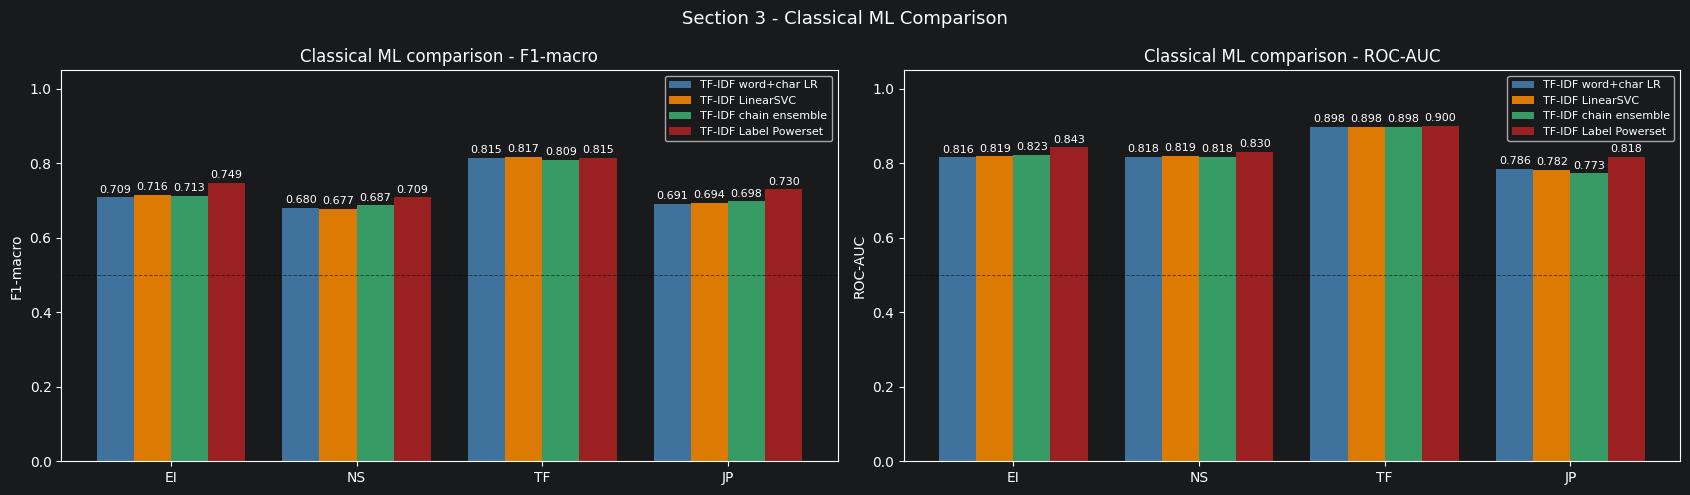

In [29]:
# Load cached classical metrics if this plotting cell is run after a kernel restart.
if "tfidf_metrics" not in globals() and (RESULTS_DIR / "tfidf_word_char_logreg.joblib").exists():
    tfidf_metrics = joblib.load(RESULTS_DIR / "tfidf_word_char_logreg.joblib")["metrics_test"]

if "tfidf_svc_metrics" not in globals() and (RESULTS_DIR / "tfidf_word_char_linearsvc.joblib").exists():
    tfidf_svc_metrics = joblib.load(RESULTS_DIR / "tfidf_word_char_linearsvc.joblib")["metrics_test"]

if "tfidf_chain_metrics" not in globals() and (RESULTS_DIR / "tfidf_chain_ensemble.joblib").exists():
    tfidf_chain_metrics = joblib.load(RESULTS_DIR / "tfidf_chain_ensemble.joblib")["meta"]["metrics_test"]

if "lp_metrics" not in globals() and (RESULTS_DIR / "tfidf_label_powerset.joblib").exists():
    lp_metrics = joblib.load(RESULTS_DIR / "tfidf_label_powerset.joblib")["meta"]["metrics_test"]

classical_metric_sources = [
    ("TF-IDF word+char LR", globals().get("tfidf_metrics")),
    ("TF-IDF LinearSVC", globals().get("tfidf_svc_metrics")),
    ("TF-IDF chain ensemble", globals().get("tfidf_chain_metrics")),
    ("TF-IDF Label Powerset", globals().get("lp_metrics")),
]

classical_rows = []
for model_name, metrics in classical_metric_sources:
    if not metrics:
        continue
    for axis in LABEL_ORDER:
        classical_rows.append({
            "model": model_name,
            "axis": axis,
            "f1_macro": metrics["per_label"][axis]["f1_macro"],
            "f1_pos": metrics["per_label"][axis]["f1_pos"],
            "roc_auc": metrics["per_label"][axis]["roc_auc"],
        })

if not classical_rows:
    raise RuntimeError("No cached classical metrics found. Run Sections 3.3-3.6 first.")

classical_compare_df = pd.DataFrame(classical_rows)
print("\n--- Classical ML comparison: F1-macro (fair binary-axis macro F1) ---")
print(classical_compare_df.pivot_table(index="model", columns="axis", values="f1_macro").round(4))
print("\n--- Classical ML comparison: F1-positive ---")
print(classical_compare_df.pivot_table(index="model", columns="axis", values="f1_pos").round(4))
print("\n--- Classical ML comparison: ROC-AUC ---")
print(classical_compare_df.pivot_table(index="model", columns="axis", values="roc_auc").round(4))

print("\n--- Classical ML macro summary ---")
print(
    classical_compare_df
    .groupby("model")[["f1_macro", "f1_pos", "roc_auc"]]
    .mean()
    .sort_values("f1_macro", ascending=False)
    .round(4)
)

fig, axes_grid = plt.subplots(1, 2, figsize=(17, 5))
model_order = [
    model_name for model_name in [
        "TF-IDF word+char LR",
        "TF-IDF LinearSVC",
        "TF-IDF chain ensemble",
        "TF-IDF Label Powerset",
    ]
    if model_name in set(classical_compare_df["model"])
]
colors = ["steelblue", "darkorange", "mediumseagreen", "firebrick"]
x = np.arange(len(LABEL_ORDER))
width = min(0.8 / len(model_order), 0.34)

ax = axes_grid[0]
for j, model_name in enumerate(model_order):
    vals = [
        classical_compare_df[(classical_compare_df["model"] == model_name) & (classical_compare_df["axis"] == axis)]["f1_macro"].iloc[0]
        for axis in LABEL_ORDER
    ]
    bars = ax.bar(x + (j - (len(model_order) - 1) / 2) * width, vals, width, label=model_name, color=colors[j], alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-macro")
ax.set_title("Classical ML comparison - F1-macro")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.legend(fontsize=8)

ax = axes_grid[1]
for j, model_name in enumerate(model_order):
    vals = [
        classical_compare_df[(classical_compare_df["model"] == model_name) & (classical_compare_df["axis"] == axis)]["roc_auc"].iloc[0]
        for axis in LABEL_ORDER
    ]
    bars = ax.bar(x + (j - (len(model_order) - 1) / 2) * width, vals, width, label=model_name, color=colors[j], alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER)
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_title("Classical ML comparison - ROC-AUC")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax.legend(fontsize=8)

plt.suptitle("Section 3 - Classical ML Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "s3_classical_comparison.png", dpi=150)
plt.show()


# 4 - Transformer Modelling

This section contains the neural modelling components. The final transformer setup uses one shared encoder with four output heads, one for each MBTI axis.

The older separate per-axis transformer setup was removed because it trains independent models and does not share information across MBTI axes. The current approach is closer to the intended multilabel architecture: one model sees the same user text and predicts all four axes jointly.


## 4.1 - Shared-Encoder Multi-Label Transformers

This is the main neural MBTI experiment.

Architecture:

- A pretrained transformer encoder reads chunks of each user's text.
- Four independent linear heads predict `EI`, `NS`, `TF`, and `JP` from the shared representation.
- Long user histories are split into chunks, and chunk-level probabilities are averaged back to the user level.

Models available in the configuration include MentalRoBERTa, RoBERTa-base, and a long-context ModernBERT ablation. The active run list controls which models are trained in the current execution.


## 4.2 - Shared-Transformer Configuration

Defines active model choices, training settings, per-model hyperparameters, and typed config accessors.


In [30]:
MULTILABEL_TRANSFORMER_RESULTS_PATH = RESULTS_DIR / "multilabel_transformer_metrics.csv"
# Rerun MentalRoBERTa to regenerate clean axis-only shared-transformer metrics.
RUN_MULTILABEL_MODELS = [
    "mentalroberta",
]
# Chunking gives the transformer more of each user's writing while keeping runtime bounded.
MULTILABEL_EPOCHS = 5
dataloader_workers = int(cast(Any, globals().get("DATALOADER_WORKERS", 0)))
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
MULTILABEL_TRAIN_BATCH = int(cast(Any, globals().get("TRAIN_BATCH", 8)))
MULTILABEL_EVAL_BATCH = int(cast(Any, globals().get("EVAL_BATCH", 16)))
MULTILABEL_POS_WEIGHT_MODE = "sqrt_clipped"  # options: "sqrt_clipped", "raw", "none"
MULTILABEL_POS_WEIGHT_CLIP = (0.5, 3.0)
MULTILABEL_CHUNK_WORDS = 260
MULTILABEL_MAX_TRAIN_CHUNKS = 3
MULTILABEL_MAX_EVAL_CHUNKS = 5
MULTILABEL_EXPERIMENT_TAG = "chunkavg_axisonly_v6"

def make_model_config(**kwargs: Any) -> dict[str, Any]:
    return dict(kwargs)


MULTILABEL_MODEL_CONFIGS: dict[str, dict[str, Any]] = {
    "mentalroberta": make_model_config(
        checkpoint="mental/mental-roberta-base",
        max_len=512,
        tokenizer_kwargs={},
        drop_token_type_ids=True,
        lr=2e-5,
        pooling="mean",
        dropout=0.1,
        chunk_words=260,
        max_train_chunks=3,
        max_eval_chunks=5,
    ),
    "roberta_base": make_model_config(
        checkpoint="roberta-base",
        max_len=512,
        tokenizer_kwargs={},
        drop_token_type_ids=True,
        lr=2e-5,
        pooling="mean",
        dropout=0.1,
        chunk_words=260,
        max_train_chunks=3,
        max_eval_chunks=5,
        train_batch=8,
        eval_batch=16,
    ),
    "deberta_v3_base": make_model_config(
        checkpoint="microsoft/deberta-v3-base",
        max_len=512,
        tokenizer_kwargs={"use_fast": False},
        drop_token_type_ids=True,
        lr=1e-5,
        pooling="mean",
        dropout=0.1,
        chunk_words=260,
        max_train_chunks=3,
        max_eval_chunks=5,
        train_batch=8,
        eval_batch=16,
    ),
    "modernbert_long": make_model_config(
        checkpoint="answerdotai/ModernBERT-base",
        max_len=768,
        tokenizer_kwargs={},
        drop_token_type_ids=True,
        lr=1e-5,
        pooling="mean",
        dropout=0.1,
        chunk_words=500,
        max_train_chunks=2,
        max_eval_chunks=2,
        train_batch=4,
        eval_batch=8,
    ),
}


def cfg_value(cfg: dict[str, Any], key: str, default: Any) -> Any:
    return cast(Any, cfg.get(key, default))


def cfg_int(cfg: dict[str, Any], key: str, default: int) -> int:
    value = cfg_value(cfg, key, default)
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, str):
        return int(value)
    return int(default)


def cfg_float(cfg: dict[str, Any], key: str, default: float) -> float:
    value = cfg_value(cfg, key, default)
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    if isinstance(value, str):
        return float(value)
    return float(default)


def cfg_bool(cfg: dict[str, Any], key: str, default: bool) -> bool:
    value = cfg_value(cfg, key, default)
    return bool(value) if isinstance(value, (bool, int, np.integer)) else bool(default)


def cfg_str(cfg: dict[str, Any], key: str, default: str) -> str:
    value = cfg_value(cfg, key, default)
    return value if isinstance(value, str) else default


def cfg_dict(cfg: dict[str, Any], key: str) -> dict[str, Any]:
    value = cfg_value(cfg, key, {})
    return dict(value) if isinstance(value, dict) else {}

## 4.3 - Split Rebuild and Text Chunking

Rebuilds the same Kaggle user split used elsewhere and converts long user histories into a bounded number of text chunks.


In [31]:
def clean_transformer_text_multilabel(text: str) -> str:
    """Fallback copy of the Section 4 transformer cleaner for standalone reruns."""
    transformer_cleaner = globals().get("clean_transformer_text")
    if callable(transformer_cleaner):
        return transformer_cleaner(text)
    if not isinstance(text, str):
        return ""
    t = re.sub(r"\|+", ". ", text)
    for mbti in [x.lower() for x in MBTI_TYPES]:
        t = re.sub(rf"\b{mbti}\b", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def keep_head_tail_words_multilabel(text: str, max_words: int = 900) -> str:
    words = str(text).split()
    if len(words) <= max_words:
        return str(text)
    half = max_words // 2
    return " ".join(words[:half] + words[-half:])


def build_multilabel_transformer_splits() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build the same 70/15/15 Kaggle user split used by the transformer section."""
    raw = pd.read_csv(DATA_DIR / "mbti_1.csv")
    raw.columns = raw.columns.str.strip().str.lower()
    raw = raw.rename(columns={"type": "mbti_type", "posts": "posts_raw"})
    raw["mbti_type"] = raw["mbti_type"].str.upper().str.strip()
    for axis, (pos, _) in AXES.items():
        raw[axis] = raw["mbti_type"].str.contains(pos, case=False).astype(int)
    raw["user_id"] = np.arange(len(raw), dtype=int)
    raw["transformer_text"] = raw["posts_raw"].map(clean_transformer_text_multilabel)
    train_split, temp_split = train_test_split(
        raw,
        test_size=0.30,
        stratify=raw["mbti_type"],
        random_state=SEED,
    )
    val_split, test_split = train_test_split(
        temp_split,
        test_size=0.50,
        stratify=temp_split["mbti_type"],
        random_state=SEED,
    )
    return train_split.reset_index(drop=True), val_split.reset_index(drop=True), test_split.reset_index(drop=True)


def select_evenly_spaced_chunks(chunks: list[str], max_chunks: int) -> list[str]:
    if len(chunks) <= max_chunks:
        return chunks
    indices = np.linspace(0, len(chunks) - 1, max_chunks).round().astype(int)
    seen = set()
    selected = []
    for idx in indices:
        idx_int = int(idx)
        if idx_int not in seen:
            selected.append(chunks[idx_int])
            seen.add(idx_int)
    return selected


def split_text_into_word_chunks(text: str, chunk_words: int, max_chunks: int) -> list[str]:
    words = str(text).split()
    if not words:
        return [""]
    chunks = [
        " ".join(words[start:start + chunk_words])
        for start in range(0, len(words), chunk_words)
    ]
    return select_evenly_spaced_chunks(chunks, max_chunks=max_chunks)


def build_multilabel_chunk_frame(user_df: pd.DataFrame, chunk_words: int, max_chunks: int) -> pd.DataFrame:
    rows = []
    for _, row in user_df.iterrows():
        chunks = split_text_into_word_chunks(
            row["transformer_text"],
            chunk_words=chunk_words,
            max_chunks=max_chunks,
        )
        for chunk_idx, chunk_text in enumerate(chunks):
            item = {
                "user_id": int(row["user_id"]),
                "chunk_id": int(chunk_idx),
                "chunk_text": chunk_text,
                "mbti_type": row["mbti_type"],
            }
            for axis in LABEL_ORDER:
                item[axis] = int(row[axis])
            rows.append(item)
    return pd.DataFrame(rows).reset_index(drop=True)

## 4.4 - Multi-Label Dataset and Model

Defines the chunk-level dataset and the shared encoder with four axis-specific output heads.


In [32]:
def tokenize_head_tail(texts, tokenizer, max_len: int) -> dict[str, torch.Tensor]:
    """Preserve beginning and ending tokens of long user histories."""
    encoded_rows = []
    token_budget = max_len - tokenizer.num_special_tokens_to_add(pair=False)
    for text in texts:
        token_ids = tokenizer(str(text), add_special_tokens=False, truncation=False, verbose=False)["input_ids"]
        if len(token_ids) > token_budget:
            head_len = token_budget // 2
            tail_len = token_budget - head_len
            token_ids = token_ids[:head_len] + token_ids[-tail_len:]
        encoded_rows.append(tokenizer.prepare_for_model(
            token_ids,
            add_special_tokens=True,
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
        ))
    return {key: torch.tensor([row[key] for row in encoded_rows], dtype=torch.long) for key in encoded_rows[0].keys()}

class MBTIMultiLabelDataset(Dataset):
    def __init__(self, texts, labels, user_ids, tokenizer, max_len: int, drop_token_type_ids: bool = False):
        enc = tokenize_head_tail(texts, tokenizer, max_len)
        if drop_token_type_ids and "token_type_ids" in enc:
            enc.pop("token_type_ids")
        self.encodings = enc
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.user_ids = torch.tensor(user_ids, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        item["user_id"] = self.user_ids[idx]
        return item


class MultiHeadMBTITransformer(nn.Module):
    """One shared transformer encoder with one binary head per MBTI axis."""
    def __init__(self, checkpoint: str, label_order: list[str], dropout: float = 0.1, pooling: str = "mean"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(checkpoint)
        hidden_size = int(self.encoder.config.hidden_size)
        self.dropout = nn.Dropout(dropout)
        # Separate heads share one encoder, allowing the model to learn common personality features.
        self.heads = nn.ModuleDict({axis: nn.Linear(hidden_size, 1) for axis in label_order})
        self.label_order = list(label_order)
        self.pooling = pooling

    def _pool(self, last_hidden_state: torch.Tensor, attention_mask: torch.Tensor | None) -> torch.Tensor:
        # RoBERTa pooler can be randomly initialized for base checkpoints, so use token states directly.
        if self.pooling == "cls" or attention_mask is None:
            return last_hidden_state[:, 0]
        mask = attention_mask.unsqueeze(-1).to(dtype=last_hidden_state.dtype)
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1.0)
        return summed / counts

    def forward(self, labels=None, **batch):
        attention_mask = batch.get("attention_mask")
        outputs = self.encoder(**batch)
        pooled = self._pool(outputs.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)
        logits = torch.cat([self.heads[axis](pooled) for axis in self.label_order], dim=1)
        return SimpleNamespace(logits=logits)

## 4.5 - Multi-Label Training and Evaluation Helpers

Defines class weighting, threshold tuning, training, and user-level chunk aggregation for evaluation.


In [33]:
def multilabel_pos_weight(y: np.ndarray, mode: str = "sqrt_clipped") -> torch.Tensor:
    positives = y.sum(axis=0)
    negatives = y.shape[0] - positives
    raw_weights = negatives / np.clip(positives, 1, None)
    if mode == "none":
        weights = np.ones_like(raw_weights, dtype=float)
    elif mode == "sqrt_clipped":
        lo, hi = MULTILABEL_POS_WEIGHT_CLIP
        weights = np.clip(np.sqrt(raw_weights), lo, hi)
    else:
        weights = raw_weights
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def tune_threshold_macro_f1_multilabel(labels: np.ndarray, probs: np.ndarray) -> tuple[float, float]:
    """Standalone threshold tuning for one binary axis using macro-F1."""
    best_t, best_f = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 91):
        preds = (probs >= t).astype(int)
        score = f1_score(labels, preds, average="macro", zero_division=0)
        if score > best_f:
            best_t, best_f = float(t), float(score)
    return best_t, best_f


def train_multilabel_epoch(model, loader, optimizer, scheduler, device, epoch: int, total_epochs: int, pos_weight: torch.Tensor):
    model.train()
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    total_loss = 0.0
    progress = tqdm(enumerate(loader), total=len(loader), desc=f"Epoch {epoch}/{total_epochs} [Multi-label]")
    for _, batch in progress:
        tensor_batch: dict[str, torch.Tensor] = {
            str(k): cast(torch.Tensor, v).to(device) for k, v in batch.items()
        }
        labels = tensor_batch.pop("labels")
        tensor_batch.pop("user_id", None)
        optimizer.zero_grad(set_to_none=True)
        logits = model(**tensor_batch).logits
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += float(loss.item())
        progress.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate_multilabel_transformer(model, loader, device, thresholds: np.ndarray | None = None, tune_thresholds: bool = False):
    model.eval()
    all_labels = []
    all_probs = []
    all_user_ids = []
    for batch in tqdm(loader, desc="Evaluating multi-label chunks"):
        tensor_batch: dict[str, torch.Tensor] = {
            str(k): cast(torch.Tensor, v).to(device) for k, v in batch.items()
        }
        labels = tensor_batch.pop("labels")
        user_ids = tensor_batch.pop("user_id")
        logits = model(**tensor_batch).logits
        probs = torch.sigmoid(logits)
        all_labels.append(labels.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())
        all_user_ids.append(user_ids.detach().cpu().numpy())
    labels_chunk_np = np.vstack(all_labels).astype(int)
    probs_chunk_np = np.vstack(all_probs)
    user_ids_np = np.concatenate(all_user_ids).astype(int)

    # Aggregate chunk probabilities back to one prediction per original user.
    prob_df = pd.DataFrame(probs_chunk_np, columns=LABEL_ORDER)
    prob_df["user_id"] = user_ids_np
    probs_np = prob_df.groupby("user_id", sort=False)[LABEL_ORDER].mean().to_numpy(dtype=float)

    label_df = pd.DataFrame(labels_chunk_np, columns=LABEL_ORDER)
    label_df["user_id"] = user_ids_np
    labels_np = label_df.groupby("user_id", sort=False)[LABEL_ORDER].first().to_numpy(dtype=int)
    if tune_thresholds or thresholds is None:
        thresholds = np.array([
            tune_threshold_macro_f1_multilabel(labels_np[:, i], probs_np[:, i])[0]
            for i in range(len(LABEL_ORDER))
        ], dtype=float)
    preds_np = (probs_np >= thresholds).astype(int)
    per_label = {}
    for i, axis in enumerate(LABEL_ORDER):
        per_label[axis] = {
            "f1_macro": float(f1_score(labels_np[:, i], preds_np[:, i], average="macro", zero_division=0)),
            "f1_pos": float(f1_score(labels_np[:, i], preds_np[:, i], pos_label=1, zero_division=0)),
            "roc_auc": float(roc_auc_score(labels_np[:, i], probs_np[:, i])),
            "balanced_accuracy": float(balanced_accuracy_score(labels_np[:, i], preds_np[:, i])),
            "threshold": float(thresholds[i]),
            "true_pos_rate": float(np.mean(labels_np[:, i])),
            "pred_pos_rate": float(np.mean(preds_np[:, i])),
        }
    metrics = {
        "per_label": per_label,
        "f1_macro": float(np.mean([per_label[a]["f1_macro"] for a in LABEL_ORDER])),
        "f1_pos_macro": float(np.mean([per_label[a]["f1_pos"] for a in LABEL_ORDER])),
        "roc_macro": float(np.mean([per_label[a]["roc_auc"] for a in LABEL_ORDER])),
        "balanced_accuracy": float(np.mean([per_label[a]["balanced_accuracy"] for a in LABEL_ORDER])),
        "thresholds": thresholds.tolist(),
    }
    return metrics, labels_np, probs_np, preds_np

## 4.6 - Run Shared-Transformer Experiments

Runs the selected shared-transformer models, saves the best checkpoints, caches test outputs, and prints the transformer summary tables.


In [ ]:
ml_train_df, ml_val_df, ml_test_df = build_multilabel_transformer_splits()
multilabel_transformer_rows = []

for model_key in RUN_MULTILABEL_MODELS:
    cfg = cast(dict[str, Any], dict(MULTILABEL_MODEL_CONFIGS[model_key]))
    checkpoint = cfg_str(cfg, "checkpoint", "")
    max_len = cfg_int(cfg, "max_len", 512)
    tokenizer_kwargs = cfg_dict(cfg, "tokenizer_kwargs")
    drop_token_type_ids = cfg_bool(cfg, "drop_token_type_ids", False)
    model_chunk_words = cfg_int(cfg, "chunk_words", MULTILABEL_CHUNK_WORDS)
    model_max_train_chunks = cfg_int(cfg, "max_train_chunks", MULTILABEL_MAX_TRAIN_CHUNKS)
    model_max_eval_chunks = cfg_int(cfg, "max_eval_chunks", MULTILABEL_MAX_EVAL_CHUNKS)
    model_train_batch = cfg_int(cfg, "train_batch", MULTILABEL_TRAIN_BATCH)
    model_eval_batch = cfg_int(cfg, "eval_batch", MULTILABEL_EVAL_BATCH)
    metrics_path = RESULTS_DIR / f"multilabel_{model_key}_metrics.json"
    save_dir = RESULTS_DIR / f"multilabel_{model_key}_best"

    print("\n" + "=" * 70)
    print(f"SHARED-ENCODER MULTI-LABEL TRANSFORMER: {model_key.upper()}")
    print(f"Checkpoint: {checkpoint}")
    print("=" * 70)

    if metrics_path.exists() and (RESULTS_DIR / f"multilabel_{model_key}_test_outputs.npz").exists():
        with open(metrics_path, "r") as f:
            cached_metrics = json.load(f)
        # Ignore cached metrics if the training recipe changed.
        if cached_metrics.get("experiment_tag") == MULTILABEL_EXPERIMENT_TAG:
            print(f"Loading cached multi-label transformer metrics from {metrics_path}")
            for axis in LABEL_ORDER:
                row = {"model": f"multilabel_{model_key}", "axis": axis}
                row.update(cached_metrics["per_label"][axis])
                row["f1_macro_all_axes"] = cached_metrics["f1_macro"]
                row["roc_macro_all_axes"] = cached_metrics["roc_macro"]
                multilabel_transformer_rows.append(row)
            continue
        print("Ignoring stale cached multi-label metrics because the experiment settings changed.")

    ml_train_chunk_df = build_multilabel_chunk_frame(ml_train_df, chunk_words=model_chunk_words, max_chunks=model_max_train_chunks)
    ml_val_chunk_df = build_multilabel_chunk_frame(ml_val_df, chunk_words=model_chunk_words, max_chunks=model_max_eval_chunks)
    ml_test_chunk_df = build_multilabel_chunk_frame(ml_test_df, chunk_words=model_chunk_words, max_chunks=model_max_eval_chunks)
    print(
        "Chunk settings:",
        {
            "max_len": max_len,
            "chunk_words": model_chunk_words,
            "train_batch": model_train_batch,
            "eval_batch": model_eval_batch,
            "train_users": len(ml_train_df),
            "train_chunks": len(ml_train_chunk_df),
            "val_users": len(ml_val_df),
            "val_chunks": len(ml_val_chunk_df),
            "test_users": len(ml_test_df),
            "test_chunks": len(ml_test_chunk_df),
        },
    )

    tokenizer = AutoTokenizer.from_pretrained(checkpoint, **tokenizer_kwargs)
    y_train_user_multi = ml_train_df[LABEL_ORDER].to_numpy(dtype=np.float32)
    y_train_chunk_multi = ml_train_chunk_df[LABEL_ORDER].to_numpy(dtype=np.float32)
    y_val_chunk_multi = ml_val_chunk_df[LABEL_ORDER].to_numpy(dtype=np.float32)
    y_test_chunk_multi = ml_test_chunk_df[LABEL_ORDER].to_numpy(dtype=np.float32)

    train_ds = MBTIMultiLabelDataset(
        ml_train_chunk_df["chunk_text"].tolist(),
        y_train_chunk_multi,
        ml_train_chunk_df["user_id"].to_numpy(dtype=int),
        tokenizer,
        max_len,
        drop_token_type_ids,
    )
    val_ds = MBTIMultiLabelDataset(
        ml_val_chunk_df["chunk_text"].tolist(),
        y_val_chunk_multi,
        ml_val_chunk_df["user_id"].to_numpy(dtype=int),
        tokenizer,
        max_len,
        drop_token_type_ids,
    )
    test_ds = MBTIMultiLabelDataset(
        ml_test_chunk_df["chunk_text"].tolist(),
        y_test_chunk_multi,
        ml_test_chunk_df["user_id"].to_numpy(dtype=int),
        tokenizer,
        max_len,
        drop_token_type_ids,
    )

    train_loader = DataLoader(train_ds, batch_size=model_train_batch, shuffle=True, collate_fn=default_data_collator, num_workers=dataloader_workers)
    val_loader = DataLoader(val_ds, batch_size=model_eval_batch, shuffle=False, collate_fn=default_data_collator, num_workers=dataloader_workers)
    test_loader = DataLoader(test_ds, batch_size=model_eval_batch, shuffle=False, collate_fn=default_data_collator, num_workers=dataloader_workers)

    model = MultiHeadMBTITransformer(
        checkpoint,
        LABEL_ORDER,
        dropout=cfg_float(cfg, "dropout", 0.1),
        pooling=cfg_str(cfg, "pooling", "mean"),
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg_float(cfg, "lr", 1e-5), weight_decay=0.01)
    num_training_steps = len(train_loader) * MULTILABEL_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.10 * num_training_steps),
        num_training_steps=num_training_steps,
    )
    pos_weight = multilabel_pos_weight(y_train_user_multi, mode=MULTILABEL_POS_WEIGHT_MODE)
    print(f"Positive class weights ({MULTILABEL_POS_WEIGHT_MODE}):", dict(zip(LABEL_ORDER, pos_weight.detach().cpu().numpy().round(3).tolist())))

    best_val_f1 = -1.0
    best_thresholds = np.full(len(LABEL_ORDER), 0.5, dtype=float)
    for epoch in range(MULTILABEL_EPOCHS):
        train_loss = train_multilabel_epoch(
            model, train_loader, optimizer, scheduler, DEVICE,
            epoch=epoch + 1, total_epochs=MULTILABEL_EPOCHS, pos_weight=pos_weight,
        )
        val_metrics, val_labels, val_probs, val_preds = evaluate_multilabel_transformer(
            model, val_loader, DEVICE, tune_thresholds=True,
        )
        print(f"\nTrain loss: {train_loss:.4f} | Val F1-macro: {val_metrics['f1_macro']:.4f} | Val ROC: {val_metrics['roc_macro']:.4f}")
        print("Thresholds:", dict(zip(LABEL_ORDER, np.array(val_metrics["thresholds"]).round(2).tolist())))

        # Save the checkpoint selected by validation macro-F1, then test it once.
        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = float(val_metrics["f1_macro"])
            best_thresholds = np.array(val_metrics["thresholds"], dtype=float)
            save_dir.mkdir(parents=True, exist_ok=True)
            model.encoder.save_pretrained(save_dir / "encoder")
            tokenizer.save_pretrained(save_dir)
            torch.save({"heads": model.heads.state_dict(), "label_order": LABEL_ORDER}, save_dir / "heads.pt")
            np.savez_compressed(
                RESULTS_DIR / f"multilabel_{model_key}_val_outputs.npz",
                labels=val_labels,
                probs=val_probs,
                preds=val_preds,
                thresholds=best_thresholds,
            )

    # Evaluate the actual best validation checkpoint, not just the final epoch weights.
    best_heads_path = save_dir / "heads.pt"
    if (save_dir / "encoder").exists() and best_heads_path.exists():
        model.encoder = AutoModel.from_pretrained(save_dir / "encoder").to(DEVICE)
        best_state = torch.load(best_heads_path, map_location=DEVICE)
        model.heads.load_state_dict(best_state["heads"])

    test_metrics, test_labels, test_probs, test_preds = evaluate_multilabel_transformer(
        model, test_loader, DEVICE, thresholds=best_thresholds,
    )
    test_metrics["model"] = f"multilabel_{model_key}"
    test_metrics["checkpoint"] = checkpoint
    test_metrics["val_f1_macro"] = float(best_val_f1)
    test_metrics["experiment_tag"] = MULTILABEL_EXPERIMENT_TAG
    test_metrics["pooling"] = cfg_str(cfg, "pooling", "mean")
    test_metrics["pos_weight_mode"] = MULTILABEL_POS_WEIGHT_MODE
    test_metrics["chunk_words"] = int(model_chunk_words)
    test_metrics["max_train_chunks"] = int(model_max_train_chunks)
    test_metrics["max_eval_chunks"] = int(model_max_eval_chunks)
    test_metrics["train_batch"] = int(model_train_batch)
    test_metrics["eval_batch"] = int(model_eval_batch)

    np.savez_compressed(
        RESULTS_DIR / f"multilabel_{model_key}_test_outputs.npz",
        labels=test_labels,
        probs=test_probs,
        preds=test_preds,
        thresholds=best_thresholds,
    )
    with open(metrics_path, "w") as f:
        json.dump(test_metrics, f, indent=2)

    print("\nTEST RESULTS")
    print(f"F1-macro : {test_metrics['f1_macro']:.4f}")
    print(f"ROC-macro: {test_metrics['roc_macro']:.4f}")
    for axis, metrics in test_metrics["per_label"].items():
        print(f"  [{axis}] F1={metrics['f1_macro']:.4f} ROC={metrics['roc_auc']:.4f} threshold={metrics['threshold']:.2f}")
        row = {"model": f"multilabel_{model_key}", "axis": axis}
        row.update(metrics)
        row["f1_macro_all_axes"] = test_metrics["f1_macro"]
        row["roc_macro_all_axes"] = test_metrics["roc_macro"]
        multilabel_transformer_rows.append(row)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

multilabel_transformer_df = pd.DataFrame(multilabel_transformer_rows)
multilabel_transformer_df.to_csv(MULTILABEL_TRANSFORMER_RESULTS_PATH, index=False)

print("\n--- Shared-encoder multi-label transformer F1-macro ---")
print(multilabel_transformer_df.pivot_table(index="model", columns="axis", values="f1_macro").round(4))
print("\n--- Shared-encoder multi-label transformer ROC-AUC ---")
print(multilabel_transformer_df.pivot_table(index="model", columns="axis", values="roc_auc").round(4))
print("\n--- Shared-encoder multi-label transformer macro summary ---")
print(multilabel_transformer_df.groupby("model")[["f1_macro", "roc_auc"]].mean().round(4))

## 4.7 - Final MBTI Model Comparison

This section loads cached outputs from the classical and transformer experiments and builds the final MBTI comparison tables and plots.

Reported metrics include:

- Per-axis macro-F1.
- Per-axis ROC-AUC.
- Overall macro summaries.
- Bootstrap confidence intervals for final macro-F1 and ROC-AUC.
- Exact MBTI type accuracy from thresholded axis predictions.

This is the main section to use when comparing model performance on the held-out Kaggle MBTI test split.



--- Final MBTI comparison: F1-macro per axis ---
axis                            EI      JP      NS      TF
method                                                    
TF-IDF Label Powerset       0.7735  0.7497  0.7689  0.8321
TF-IDF Logistic Regression  0.7089  0.6906  0.6796  0.8152
TF-IDF LinearSVC            0.7164  0.6942  0.6769  0.8173
TF-IDF Classifier Chain     0.7129  0.6979  0.6874  0.8094
multilabel_mentalroberta    0.7511  0.7261  0.7190  0.8118
multilabel_roberta_base     0.7431  0.7287  0.7192  0.8142
multilabel_modernbert_long  0.5803  0.5383  0.5126  0.7237

--- Final MBTI comparison: ROC-AUC per axis ---
axis                            EI      JP      NS      TF
method                                                    
TF-IDF Label Powerset       0.8642  0.8402  0.8727  0.9180
TF-IDF Logistic Regression  0.8164  0.7860  0.8184  0.8979
TF-IDF LinearSVC            0.8190  0.7820  0.8193  0.8978
TF-IDF Classifier Chain     0.8230  0.7735  0.8178  0.8977
multilabel_menta

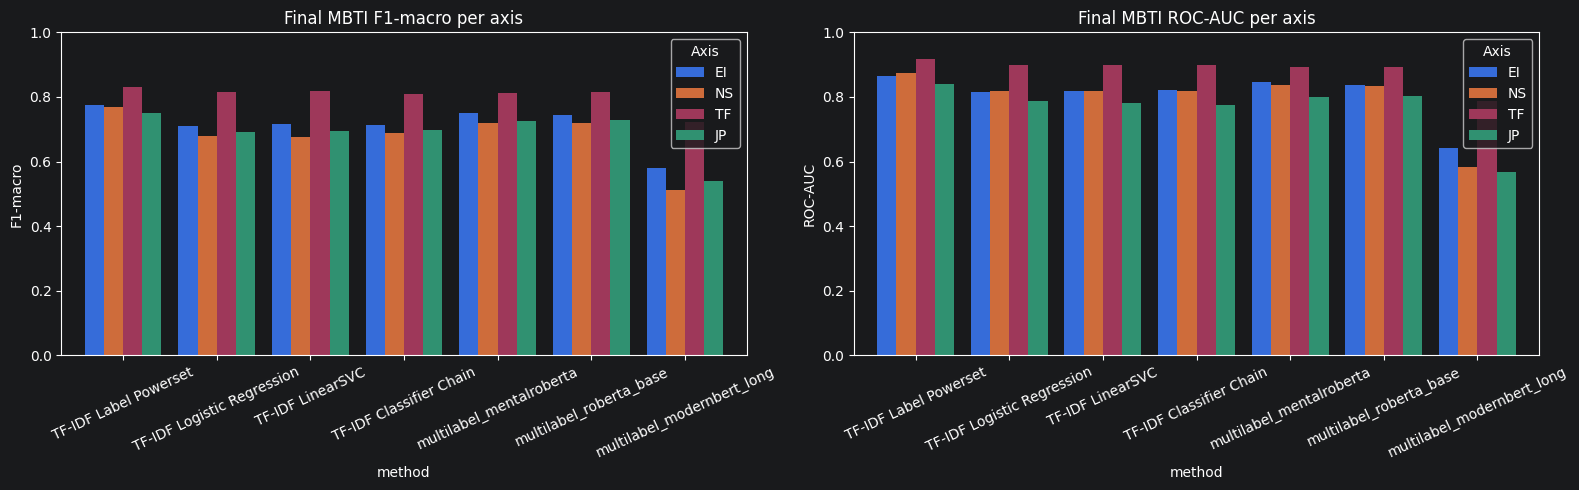

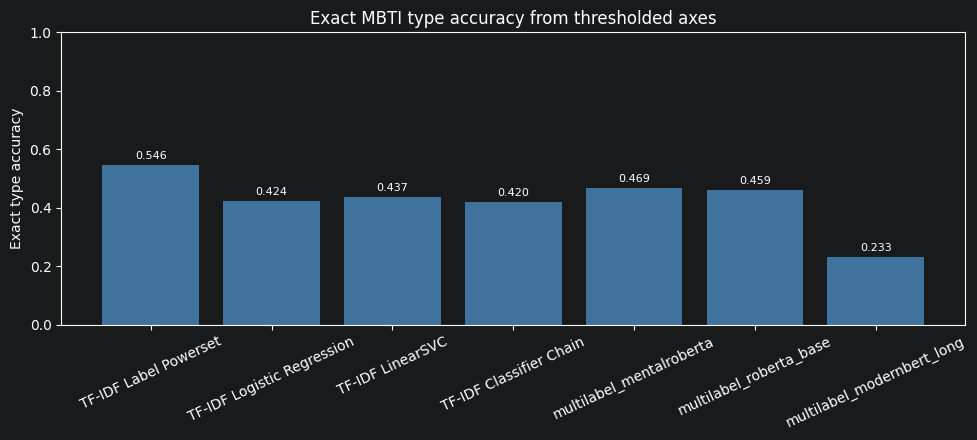

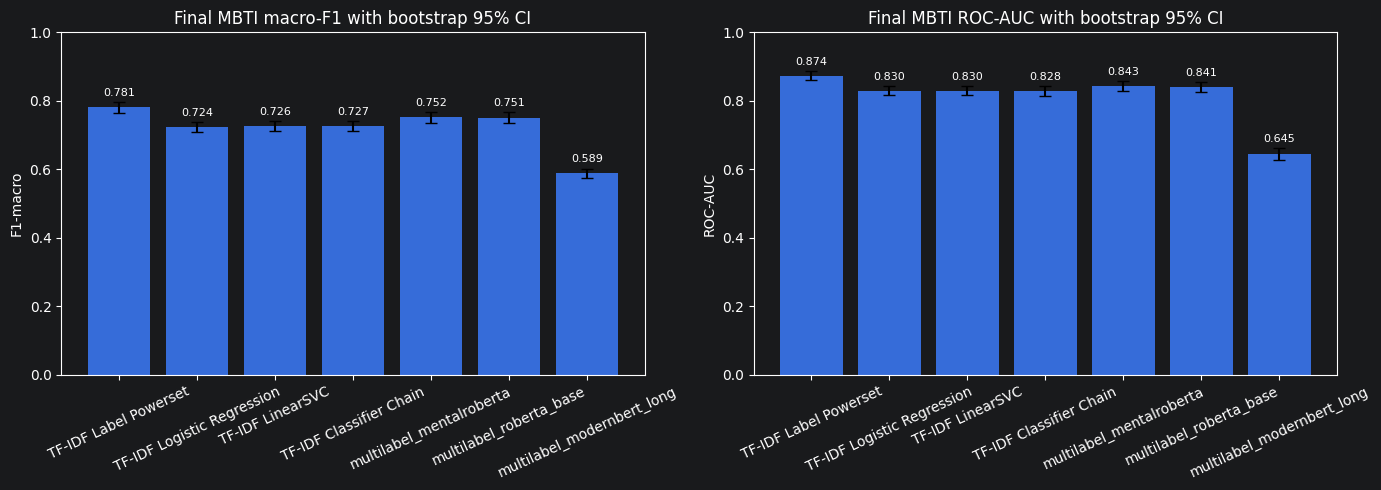


Saved final comparison to results\final_mbti_model_comparison.csv
Saved bootstrap CIs to results\final_mbti_bootstrap_ci.csv
Saved exact type accuracy to results\final_mbti_exact_type_accuracy.csv
Saved axis comparison plot to results\final_mbti_axis_comparison.png
Saved exact type accuracy plot to results\final_mbti_exact_type_accuracy.png
Saved macro CI plot to results\final_mbti_model_comparison.png


In [34]:
FINAL_MBTI_COMPARISON_PATH = RESULTS_DIR / "final_mbti_model_comparison.csv"
FINAL_MBTI_CI_PATH = RESULTS_DIR / "final_mbti_bootstrap_ci.csv"
FINAL_MBTI_EXACT_PATH = RESULTS_DIR / "final_mbti_exact_type_accuracy.csv"
FINAL_MBTI_PLOT_PATH = RESULTS_DIR / "final_mbti_model_comparison.png"
FINAL_MBTI_AXIS_PLOT_PATH = RESULTS_DIR / "final_mbti_axis_comparison.png"
FINAL_MBTI_EXACT_PLOT_PATH = RESULTS_DIR / "final_mbti_exact_type_accuracy.png"
TFIDF_LOGREG_PATH_47 = RESULTS_DIR / "tfidf_word_char_logreg.joblib"
TFIDF_SVC_PATH_47 = RESULTS_DIR / "tfidf_word_char_linearsvc.joblib"
TFIDF_CHAIN_PATH_47 = RESULTS_DIR / "tfidf_chain_ensemble.joblib"
BOOTSTRAP_N = 1000

SHARED_TRANSFORMER_METHODS = [
    "multilabel_mentalroberta",
    "multilabel_roberta_base",
    "multilabel_modernbert_long",
]
VALID_SHARED_TRANSFORMER_TAGS = {
    "chunkavg_axisonly_v5",
    "chunkavg_axisonly_v6",
}


def clean_text_for_tfidf_fallback_47(text: str) -> str:
    """Fallback copy of the Section 1 cleaner for partial reruns."""
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\|+", " ", t)
    for mbti in [x.lower() for x in MBTI_TYPES]:
        t = re.sub(rf"\b{mbti}\b", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def build_kaggle_test_split_for_final() -> pd.DataFrame:
    """Rebuild the same 70/15/15 user-level Kaggle test split used by final models."""
    raw = pd.read_csv(DATA_DIR / "mbti_1.csv")
    raw.columns = raw.columns.str.strip().str.lower()
    raw = raw.rename(columns={"type": "mbti_type", "posts": "posts_raw"})
    raw["mbti_type"] = raw["mbti_type"].str.upper().str.strip()
    for axis, (pos, _) in AXES.items():
        raw[axis] = raw["mbti_type"].str.contains(pos, case=False).astype(int)
    cleaner = clean_text_pipeline if "clean_text_pipeline" in globals() else clean_text_for_tfidf_fallback_47
    raw["clean_text"] = raw["posts_raw"].apply(cleaner)

    _, temp_df = train_test_split(
        raw,
        test_size=0.30,
        stratify=raw["mbti_type"],
        random_state=SEED,
    )
    _, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["mbti_type"],
        random_state=SEED,
    )
    return test_df.reset_index(drop=True)


def label_matrix_to_type_ids(y: np.ndarray) -> np.ndarray:
    powers = (2 ** np.arange(y.shape[1])).astype(int)
    return y.astype(int) @ powers


def macro_metrics_from_arrays(labels: np.ndarray, probs: np.ndarray, thresholds: np.ndarray) -> dict[str, float]:
    preds = (probs >= thresholds).astype(int)
    f1s = [f1_score(labels[:, i], preds[:, i], average="macro", zero_division=0) for i in range(labels.shape[1])]
    rocs = []
    for i in range(labels.shape[1]):
        try:
            rocs.append(roc_auc_score(labels[:, i], probs[:, i]))
        except ValueError:
            rocs.append(np.nan)
    return {"f1_macro": float(np.nanmean(f1s)), "roc_auc": float(np.nanmean(rocs))}


# Bootstrap CIs quantify whether close model differences are meaningful.
def bootstrap_metric_ci(labels: np.ndarray, probs: np.ndarray, thresholds: np.ndarray,
                        n_boot: int = BOOTSTRAP_N, seed: int = SEED) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    n = labels.shape[0]
    f1_values = []
    roc_values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        metrics = macro_metrics_from_arrays(labels[idx], probs[idx], thresholds)
        f1_values.append(metrics["f1_macro"])
        roc_values.append(metrics["roc_auc"])
    return {
        "f1_macro_ci_low": float(np.nanpercentile(f1_values, 2.5)),
        "f1_macro_ci_high": float(np.nanpercentile(f1_values, 97.5)),
        "roc_auc_ci_low": float(np.nanpercentile(roc_values, 2.5)),
        "roc_auc_ci_high": float(np.nanpercentile(roc_values, 97.5)),
    }


final_rows = []
final_outputs: dict[str, dict[str, np.ndarray]] = {}

# TF-IDF Label Powerset.
tfidf_path = RESULTS_DIR / "tfidf_word_char_logreg.joblib"
lp_path = RESULTS_DIR / "tfidf_label_powerset.joblib"
if not tfidf_path.exists() or not lp_path.exists():
    raise FileNotFoundError("Run Sections 3.5 and 3.8 first so TF-IDF and Label Powerset caches exist.")

tfidf_data = joblib.load(tfidf_path)
lp_data = joblib.load(lp_path)
tfidf_vectorizer_47 = tfidf_data["vectorizer"]
lp_model_47 = lp_data["model"]

# Rebuild the exact held-out Kaggle test order so cached predictions align with labels.
aligned_test_df = build_kaggle_test_split_for_final()
lp_labels = aligned_test_df[LABEL_ORDER].to_numpy(dtype=int)
X_test_lp = tfidf_vectorizer_47.transform(aligned_test_df["clean_text"].astype(str))
lp_classes = np.asarray(getattr(lp_model_47, "classes_"), dtype=int)
lp_probs = powerset_proba_to_label_proba(lp_model_47.predict_proba(X_test_lp), lp_classes)

lp_thresholds = None
if isinstance(lp_data, dict):
    lp_thresholds = lp_data.get("meta", {}).get("thresholds")
if lp_thresholds is None and (RESULTS_DIR / "tfidf_label_powerset_test_outputs.npz").exists():
    lp_thresholds = np.load(RESULTS_DIR / "tfidf_label_powerset_test_outputs.npz")["thresholds"]
if lp_thresholds is None:
    lp_thresholds = np.full(len(LABEL_ORDER), 0.5, dtype=float)
lp_thresholds = np.asarray(lp_thresholds, dtype=float)

for axis_idx, axis in enumerate(LABEL_ORDER):
    metrics = eval_binary_axis(lp_labels[:, axis_idx], lp_probs[:, axis_idx], lp_thresholds[axis_idx])
    final_rows.append({"method": "TF-IDF Label Powerset", "axis": axis, **metrics})
final_outputs["TF-IDF Label Powerset"] = {
    "labels": lp_labels,
    "probs": lp_probs,
    "thresholds": lp_thresholds,
}

# TF-IDF Logistic Regression Binary Relevance.
if TFIDF_LOGREG_PATH_47.exists():
    logreg_data = joblib.load(TFIDF_LOGREG_PATH_47)
    if "metrics_test" in logreg_data:
        logreg_metrics = logreg_data["metrics_test"]
        logreg_labels = []
        logreg_probs = []
        logreg_thresholds = []
        has_outputs = True
        for axis in LABEL_ORDER:
            output_path = RESULTS_DIR / f"tfidf_logreg_{axis}_test_outputs.npz"
            if not output_path.exists():
                has_outputs = False
                break
            output_data = np.load(output_path)
            logreg_labels.append(output_data["labels"])
            logreg_probs.append(output_data["probs"])
            logreg_thresholds.append(float(output_data["threshold"][0] if output_data["threshold"].ndim else output_data["threshold"]))
            final_rows.append({"method": "TF-IDF Logistic Regression", "axis": axis, **logreg_metrics["per_label"][axis]})
        if has_outputs:
            final_outputs["TF-IDF Logistic Regression"] = {
                "labels": np.column_stack(logreg_labels),
                "probs": np.column_stack(logreg_probs),
                "thresholds": np.asarray(logreg_thresholds, dtype=float),
            }
else:
    print("Skipping TF-IDF Logistic Regression: missing cached model.")

# TF-IDF LinearSVC Binary Relevance.
if TFIDF_SVC_PATH_47.exists():
    svc_data = joblib.load(TFIDF_SVC_PATH_47)
    if "metrics_test" in svc_data:
        svc_metrics = svc_data["metrics_test"]
        svc_labels = []
        svc_probs = []
        svc_thresholds = []
        has_outputs = True
        for axis in LABEL_ORDER:
            output_path = RESULTS_DIR / f"tfidf_linearsvc_{axis}_test_outputs.npz"
            if not output_path.exists():
                has_outputs = False
                break
            output_data = np.load(output_path)
            svc_labels.append(output_data["labels"])
            svc_probs.append(output_data["probs"])
            svc_thresholds.append(float(output_data["threshold"][0] if output_data["threshold"].ndim else output_data["threshold"]))
            final_rows.append({"method": "TF-IDF LinearSVC", "axis": axis, **svc_metrics["per_label"][axis]})
        if has_outputs:
            final_outputs["TF-IDF LinearSVC"] = {
                "labels": np.column_stack(svc_labels),
                "probs": np.column_stack(svc_probs),
                "thresholds": np.asarray(svc_thresholds, dtype=float),
            }
else:
    print("Skipping TF-IDF LinearSVC: missing cached model.")

# TF-IDF classifier-chain ensemble.
chain_outputs_file = RESULTS_DIR / "tfidf_chain_test_outputs.npz"
if TFIDF_CHAIN_PATH_47.exists() and chain_outputs_file.exists():
    chain_data = joblib.load(TFIDF_CHAIN_PATH_47)
    chain_outputs = np.load(chain_outputs_file)
    chain_labels = chain_outputs["labels"]
    chain_probs = chain_outputs["probs"]
    chain_thresholds = np.asarray(chain_outputs["thresholds"], dtype=float)
    for axis_idx, axis in enumerate(LABEL_ORDER):
        metrics = eval_binary_axis(chain_labels[:, axis_idx], chain_probs[:, axis_idx], chain_thresholds[axis_idx])
        final_rows.append({"method": "TF-IDF Classifier Chain", "axis": axis, **metrics})
    final_outputs["TF-IDF Classifier Chain"] = {
        "labels": chain_labels,
        "probs": chain_probs,
        "thresholds": chain_thresholds,
    }
else:
    print("Skipping TF-IDF Classifier Chain: missing cached model or outputs.")

# Shared 4-head transformer models.
for method in SHARED_TRANSFORMER_METHODS:
    metrics_file = RESULTS_DIR / f"{method}_metrics.json"
    outputs_file = RESULTS_DIR / f"{method}_test_outputs.npz"
    if not metrics_file.exists() or not outputs_file.exists():
        print(f"Skipping {method}: missing cached metrics or outputs.")
        continue
    with open(metrics_file, "r") as f:
        cached_metrics = json.load(f)
    if cached_metrics.get("experiment_tag") not in VALID_SHARED_TRANSFORMER_TAGS:
        print(f"Skipping stale shared-transformer metrics: {metrics_file}")
        continue
    for axis in LABEL_ORDER:
        row = {"method": method, "axis": axis}
        row.update(cached_metrics["per_label"][axis])
        final_rows.append(row)
    out = np.load(outputs_file)
    final_outputs[method] = {
        "labels": out["labels"],
        "probs": out["probs"],
        "thresholds": out["thresholds"],
    }

final_df = pd.DataFrame(final_rows)
method_order = [method for method in ["TF-IDF Label Powerset", "TF-IDF Logistic Regression", "TF-IDF LinearSVC", "TF-IDF Classifier Chain", *SHARED_TRANSFORMER_METHODS]
                if method in set(final_df["method"].astype(str))]
final_df["method"] = pd.Categorical(final_df["method"], categories=method_order, ordered=True)
final_df = final_df.sort_values(["method", "axis"]).reset_index(drop=True)

final_macro_summary = (
    final_df
    .groupby("method", observed=True)[["f1_macro", "f1_pos", "roc_auc", "balanced_accuracy"]]
    .mean()
    .reset_index()
)
final_macro_summary["best_f1_macro"] = final_macro_summary["f1_macro"] == final_macro_summary["f1_macro"].max()
final_macro_summary["best_roc_auc"] = final_macro_summary["roc_auc"] == final_macro_summary["roc_auc"].max()

ci_rows = []
for method in method_order:
    out = final_outputs.get(method)
    if out is None:
        continue
    point = macro_metrics_from_arrays(out["labels"], out["probs"], out["thresholds"])
    ci = bootstrap_metric_ci(out["labels"], out["probs"], out["thresholds"])
    ci_rows.append({"method": method, **point, **ci})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(FINAL_MBTI_CI_PATH, index=False)

exact_rows = []
for method in method_order:
    out = final_outputs.get(method)
    if out is None:
        continue
    exact_threshold = float(np.mean(
        label_matrix_to_type_ids(out["labels"]) ==
        label_matrix_to_type_ids((out["probs"] >= out["thresholds"]).astype(int))
    ))
    exact_rows.append({
        "method": method,
        "exact_type_accuracy_thresholded_axes": exact_threshold,
        "exact_type_accuracy_lp_argmax": np.nan,
    })

try:
    lp_exact_argmax = float(np.mean(lp_model_47.predict(X_test_lp) == label_matrix_to_type_ids(lp_labels)))
    for row in exact_rows:
        if row["method"] == "TF-IDF Label Powerset":
            row["exact_type_accuracy_lp_argmax"] = lp_exact_argmax
except Exception:
    pass

# Exact type accuracy combines the four thresholded axes into one MBTI type.
exact_df = pd.DataFrame(exact_rows)
exact_df.to_csv(FINAL_MBTI_EXACT_PATH, index=False)

final_macro_summary = final_macro_summary.merge(
    ci_df[["method", "f1_macro_ci_low", "f1_macro_ci_high", "roc_auc_ci_low", "roc_auc_ci_high"]],
    on="method",
    how="left",
)
final_macro_summary.to_csv(FINAL_MBTI_COMPARISON_PATH, index=False)

print("\n--- Final MBTI comparison: F1-macro per axis ---")
print(final_df.pivot_table(index="method", columns="axis", values="f1_macro", observed=False).round(4))

print("\n--- Final MBTI comparison: ROC-AUC per axis ---")
print(final_df.pivot_table(index="method", columns="axis", values="roc_auc", observed=False).round(4))

print("\n--- Final MBTI macro summary with bootstrap 95% CIs ---")
print(final_macro_summary.round(4))

print("\n--- Exact MBTI type accuracy ---")
print(exact_df.round(4))

# Per-axis comparison plots.
f1_axis = final_df.pivot_table(index="method", columns="axis", values="f1_macro", observed=False).loc[method_order, LABEL_ORDER]
roc_axis = final_df.pivot_table(index="method", columns="axis", values="roc_auc", observed=False).loc[method_order, LABEL_ORDER]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
f1_axis.plot(kind="bar", ax=axes[0], width=0.82)
axes[0].set_title("Final MBTI F1-macro per axis")
axes[0].set_ylabel("F1-macro")
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Axis")
roc_axis.plot(kind="bar", ax=axes[1], width=0.82)
axes[1].set_title("Final MBTI ROC-AUC per axis")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Axis")
plt.tight_layout()
plt.savefig(FINAL_MBTI_AXIS_PLOT_PATH, dpi=150)
plt.show()

# Exact full-type accuracy from thresholded axis predictions.
exact_plot_df = exact_df.dropna(subset=["exact_type_accuracy_thresholded_axes"]).copy()
if not exact_plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(exact_plot_df["method"].astype(str), exact_plot_df["exact_type_accuracy_thresholded_axes"], color="steelblue", alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_title("Exact MBTI type accuracy from thresholded axes")
    ax.set_ylabel("Exact type accuracy")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(FINAL_MBTI_EXACT_PLOT_PATH, dpi=150)
    plt.show()

plot_summary = final_macro_summary.dropna(subset=["f1_macro_ci_low", "f1_macro_ci_high"]).copy()
if not plot_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    f1_yerr = np.vstack([
        np.maximum(plot_summary["f1_macro"] - plot_summary["f1_macro_ci_low"], 0),
        np.maximum(plot_summary["f1_macro_ci_high"] - plot_summary["f1_macro"], 0),
    ])
    bars = axes[0].bar(plot_summary["method"].astype(str), plot_summary["f1_macro"], yerr=f1_yerr, capsize=4)
    axes[0].bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    axes[0].set_title("Final MBTI macro-F1 with bootstrap 95% CI")
    axes[0].set_ylabel("F1-macro")
    axes[0].set_ylim(0, 1.0)
    axes[0].tick_params(axis="x", rotation=25)

    roc_yerr = np.vstack([
        np.maximum(plot_summary["roc_auc"] - plot_summary["roc_auc_ci_low"], 0),
        np.maximum(plot_summary["roc_auc_ci_high"] - plot_summary["roc_auc"], 0),
    ])
    bars = axes[1].bar(plot_summary["method"].astype(str), plot_summary["roc_auc"], yerr=roc_yerr, capsize=4)
    axes[1].bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    axes[1].set_title("Final MBTI ROC-AUC with bootstrap 95% CI")
    axes[1].set_ylabel("ROC-AUC")
    axes[1].set_ylim(0, 1.0)
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(FINAL_MBTI_PLOT_PATH, dpi=150)
    plt.show()

print(f"\nSaved final comparison to {FINAL_MBTI_COMPARISON_PATH}")
print(f"Saved bootstrap CIs to {FINAL_MBTI_CI_PATH}")
print(f"Saved exact type accuracy to {FINAL_MBTI_EXACT_PATH}")
print(f"Saved axis comparison plot to {FINAL_MBTI_AXIS_PLOT_PATH}")
print(f"Saved exact type accuracy plot to {FINAL_MBTI_EXACT_PLOT_PATH}")
print(f"Saved macro CI plot to {FINAL_MBTI_PLOT_PATH}")

# 5 - Zero-Shot Transfer to Pandora OCEAN

This section checks whether MBTI-trained models capture personality signals that transfer to Big Five/OCEAN traits.

Procedure:

- Apply the final MBTI models to Pandora text.
- Extract each model's MBTI axis probabilities.
- Compare those probabilities against related OCEAN traits using Pearson correlation, Spearman correlation, and median-split AUC.

Expected MBTI-to-OCEAN links used are here:

- `P(E)` -> extraversion
- `P(N)` -> openness
- `P(J)` -> conscientiousness
- `P(F) = 1 - P(T)` -> agreeableness

Pandora is not treated as an MBTI-labelled dataset. This section is an external validity and transfer analysis, not a second MBTI test set.


## 5.1 - Pandora Transfer Configuration

This cell defines the Pandora split, output paths, expected MBTI-to-OCEAN links, and the final MBTI models used for transfer analysis.


In [35]:
PANDORA_DIR = DATA_DIR / "pandora_subset"
PANDORA_SPLIT = "eval"
PANDORA_PATH = PANDORA_DIR / f"{PANDORA_SPLIT}_set.csv"
PANDORA_PROBS_PATH = RESULTS_DIR / f"pandora_{PANDORA_SPLIT}_final_mbti_axis_probs.csv"
PANDORA_SUMMARY_PATH = RESULTS_DIR / f"pandora_{PANDORA_SPLIT}_final_ocean_transfer_summary.csv"
PANDORA_ALL_PAIRS_PATH = RESULTS_DIR / f"pandora_{PANDORA_SPLIT}_final_all_axis_ocean_correlations.csv"
PANDORA_TRANSFER_PLOT_PATH = RESULTS_DIR / f"pandora_{PANDORA_SPLIT}_final_ocean_transfer.png"
# Set True only when saved model predictions should be regenerated.
PANDORA_FORCE_RECOMPUTE = False

OCEAN_TRAITS = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]

# Axis probability direction: every MBTI model outputs P(first letter in AXES[axis]).
OCEAN_TRANSFER_MAP = {
    "EI": {"trait": "extraversion", "score_name": "P(E)", "score_transform": lambda p: p},
    "NS": {"trait": "openness", "score_name": "P(N)", "score_transform": lambda p: p},
    "JP": {"trait": "conscientiousness", "score_name": "P(J)", "score_transform": lambda p: p},
    "TF": {"trait": "agreeableness", "score_name": "P(F)=1-P(T)", "score_transform": lambda p: 1.0 - p},
}

PANDORA_TFIDF_MODELS = {
    "tfidf_label_powerset": "TF-IDF Label Powerset",
    "tfidf_logreg": "TF-IDF Logistic Regression",
    "tfidf_linearsvc": "TF-IDF LinearSVC",
    "tfidf_chain": "TF-IDF Classifier Chain",
}

PANDORA_SHARED_TRANSFORMER_CONFIGS: dict[str, dict[str, Any]] = {
    "multilabel_mentalroberta": {
        "display": "MentalRoBERTa 4-head",
        "checkpoint": "mental/mental-roberta-base",
        "max_len": 512,
        "drop_token_type_ids": True,
        "pooling": "mean",
        "chunk_words": 260,
        "max_eval_chunks": 5,
        "eval_batch": 64,
    },
    "multilabel_roberta_base": {
        "display": "RoBERTa-base 4-head",
        "checkpoint": "roberta-base",
        "max_len": 512,
        "drop_token_type_ids": True,
        "pooling": "mean",
        "chunk_words": 260,
        "max_eval_chunks": 5,
        "eval_batch": 16,
    },
    "multilabel_modernbert_long": {
        "display": "ModernBERT-long 4-head",
        "checkpoint": "answerdotai/ModernBERT-base",
        "max_len": 768,
        "drop_token_type_ids": True,
        "pooling": "mean",
        "chunk_words": 500,
        "max_eval_chunks": 2,
        "eval_batch": 8,
    },
}


def pandora_cfg_value(cfg: dict[str, Any], key: str, default: Any) -> Any:
    return cast(Any, cfg.get(key, default))


def pandora_cfg_int(cfg: dict[str, Any], key: str, default: int) -> int:
    value = pandora_cfg_value(cfg, key, default)
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, str):
        return int(value)
    return int(default)


def pandora_cfg_bool(cfg: dict[str, Any], key: str, default: bool) -> bool:
    value = pandora_cfg_value(cfg, key, default)
    return bool(value) if isinstance(value, (bool, int, np.integer)) else bool(default)


def pandora_cfg_str(cfg: dict[str, Any], key: str, default: str) -> str:
    value = pandora_cfg_value(cfg, key, default)
    return value if isinstance(value, str) else default

## 5.2 - Pandora Loading and Classical Model Predictions

This cell prepares Pandora text and defines inference helpers for the cached TF-IDF classical models. It adds one probability column per MBTI axis and model.


In [36]:
def clean_transformer_text_pandora(text: str) -> str:
    transformer_cleaner = globals().get("clean_transformer_text")
    if callable(transformer_cleaner):
        return transformer_cleaner(text)
    if not isinstance(text, str):
        return ""
    t = re.sub(r"\|+", ". ", text)
    for mbti in [x.lower() for x in MBTI_TYPES]:
        t = re.sub(rf"\b{mbti}\b", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def clean_text_for_tfidf_pandora(text: str) -> str:
    if "clean_text_pipeline" in globals():
        return clean_text_pipeline(text, keep_case=False)
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\|+", " ", t)
    for mbti in [x.lower() for x in MBTI_TYPES]:
        t = re.sub(rf"\b{mbti}\b", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def load_pandora_split_final(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["text"] = df["text"].fillna("").astype(str)
    df["transformer_text"] = df["text"].map(clean_transformer_text_pandora)
    df["clean_text"] = df["text"].map(clean_text_for_tfidf_pandora)
    df = df[df["transformer_text"].str.len() >= 10].reset_index(drop=True)
    df["pandora_id"] = np.arange(len(df), dtype=int)
    return df


def ensemble_proba_pandora(chains: list, X) -> np.ndarray:
    probas = []
    for chain in chains:
        try:
            p = chain.predict_proba(X)
        except Exception:
            per_label = []
            for estimator in chain.estimators_:
                try:
                    score = estimator.decision_function(X)
                except Exception:
                    score = estimator.predict_proba(X)[:, 1]
                per_label.append(1.0 / (1.0 + np.exp(-score)))
            p = np.vstack(per_label).T
        probas.append(p)
    return np.mean(probas, axis=0)


def add_axis_probability_columns(df: pd.DataFrame, model_key: str, probs: np.ndarray) -> None:
    for axis_idx, axis in enumerate(LABEL_ORDER):
        df[f"{model_key}_{axis}_prob"] = probs[:, axis_idx]


def axis_model_entry_to_probability(axis_entry: Any, X) -> np.ndarray:
    """Return P(axis=1) from cached axis model entries saved either directly or inside metadata dicts."""
    estimator = axis_entry.get("model") if isinstance(axis_entry, dict) else axis_entry
    if estimator is None:
        raise ValueError("Cached axis model entry does not contain a fitted estimator.")
    if hasattr(estimator, "predict_proba"):
        return np.asarray(estimator.predict_proba(X)[:, 1], dtype=float)
    if hasattr(estimator, "decision_function"):
        scores = np.asarray(estimator.decision_function(X), dtype=float)
        return 1.0 / (1.0 + np.exp(-scores))
    return np.asarray(estimator.predict(X), dtype=float)


def add_tfidf_pandora_predictions(df: pd.DataFrame) -> None:
    tfidf_path = RESULTS_DIR / "tfidf_word_char_logreg.joblib"
    if not tfidf_path.exists():
        print("Skipping TF-IDF Pandora predictions: missing TF-IDF vectorizer cache.")
        return
    tfidf_vectorizer = joblib.load(tfidf_path)["vectorizer"]
    X = tfidf_vectorizer.transform(df["clean_text"].astype(str))

    lp_path = RESULTS_DIR / "tfidf_label_powerset.joblib"
    if lp_path.exists() and not all(f"tfidf_label_powerset_{axis}_prob" in df.columns for axis in LABEL_ORDER):
        lp_model = joblib.load(lp_path)["model"]
        lp_classes = np.asarray(getattr(lp_model, "classes_"), dtype=int)
        probs = powerset_proba_to_label_proba(lp_model.predict_proba(X), lp_classes)
        add_axis_probability_columns(df, "tfidf_label_powerset", probs)

    logreg_path = RESULTS_DIR / "tfidf_word_char_logreg.joblib"
    if logreg_path.exists() and not all(f"tfidf_logreg_{axis}_prob" in df.columns for axis in LABEL_ORDER):
        logreg_data = joblib.load(logreg_path)
        axis_models = logreg_data.get("axis_models", {})
        probs = np.column_stack([axis_model_entry_to_probability(axis_models[axis], X) for axis in LABEL_ORDER])
        add_axis_probability_columns(df, "tfidf_logreg", probs)

    svc_path = RESULTS_DIR / "tfidf_word_char_linearsvc.joblib"
    if svc_path.exists() and not all(f"tfidf_linearsvc_{axis}_prob" in df.columns for axis in LABEL_ORDER):
        svc_data = joblib.load(svc_path)
        axis_models = svc_data.get("axis_models", {})
        probs = np.column_stack([axis_model_entry_to_probability(axis_models[axis], X) for axis in LABEL_ORDER])
        add_axis_probability_columns(df, "tfidf_linearsvc", probs)

    chain_path = RESULTS_DIR / "tfidf_chain_ensemble.joblib"
    if chain_path.exists() and not all(f"tfidf_chain_{axis}_prob" in df.columns for axis in LABEL_ORDER):
        chain_data = joblib.load(chain_path)
        probs = ensemble_proba_pandora(chain_data["chains"], X)
        add_axis_probability_columns(df, "tfidf_chain", probs)

## 5.3 - Shared-Transformer Predictions on Pandora

This cell chunks Pandora text, loads saved shared-encoder MBTI checkpoints, averages chunk probabilities back to the user level, and appends transformer MBTI-axis probabilities.


In [37]:
def select_evenly_spaced_chunks_pandora(chunks: list[str], max_chunks: int) -> list[str]:
    if len(chunks) <= max_chunks:
        return chunks
    indices = np.linspace(0, len(chunks) - 1, max_chunks).round().astype(int)
    selected = []
    seen = set()
    for idx in indices:
        idx_int = int(idx)
        if idx_int not in seen:
            selected.append(chunks[idx_int])
            seen.add(idx_int)
    return selected


def split_text_into_chunks_pandora(text: str, chunk_words: int, max_chunks: int) -> list[str]:
    words = str(text).split()
    if not words:
        return [""]
    chunks = [" ".join(words[start:start + chunk_words]) for start in range(0, len(words), chunk_words)]
    return select_evenly_spaced_chunks_pandora(chunks, max_chunks=max_chunks)


class PandoraTextChunkDataset(Dataset):
    def __init__(self, texts, user_ids, tokenizer, max_len: int, drop_token_type_ids: bool = False):
        enc = self._tokenize_head_tail(texts, tokenizer, max_len)
        if drop_token_type_ids and "token_type_ids" in enc:
            enc.pop("token_type_ids")
        self.encodings = enc
        self.user_ids = torch.tensor(user_ids, dtype=torch.long)

    @staticmethod
    def _tokenize_head_tail(texts, tokenizer, max_len):
        encoded_rows = []
        token_budget = max_len - tokenizer.num_special_tokens_to_add(pair=False)
        for text in texts:
            token_ids = tokenizer(str(text), add_special_tokens=False, truncation=False, verbose=False)["input_ids"]
            if len(token_ids) > token_budget:
                head_len = token_budget // 2
                tail_len = token_budget - head_len
                token_ids = token_ids[:head_len] + token_ids[-tail_len:]
            encoded_rows.append(tokenizer.prepare_for_model(
                token_ids,
                add_special_tokens=True,
                max_length=max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
            ))
        return {key: torch.tensor([row[key] for row in encoded_rows], dtype=torch.long) for key in encoded_rows[0].keys()}

    def __len__(self):
        return len(self.user_ids)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["pandora_id"] = self.user_ids[idx]
        return item


class PandoraSharedMBTITransformer(nn.Module):
    def __init__(self, checkpoint: str, label_order: list[str], pooling: str = "mean", dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(checkpoint)
        hidden_size = int(self.encoder.config.hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({axis: nn.Linear(hidden_size, 1) for axis in label_order})
        self.label_order = list(label_order)
        self.pooling = pooling

    def _pool(self, last_hidden_state: torch.Tensor, attention_mask: torch.Tensor | None) -> torch.Tensor:
        if self.pooling == "cls" or attention_mask is None:
            return last_hidden_state[:, 0]
        mask = attention_mask.unsqueeze(-1).to(dtype=last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

    def forward(self, **batch):
        attention_mask = batch.get("attention_mask")
        outputs = self.encoder(**batch)
        pooled = self.dropout(self._pool(outputs.last_hidden_state, attention_mask))
        logits = torch.cat([self.heads[axis](pooled) for axis in self.label_order], dim=1)
        return SimpleNamespace(logits=logits)


@torch.no_grad()
def predict_shared_transformer_on_pandora(df: pd.DataFrame, model_key: str, cfg: dict[str, Any]) -> np.ndarray | None:
    save_dir = RESULTS_DIR / f"{model_key}_best"
    heads_path = save_dir / "heads.pt"
    if not save_dir.exists() or not heads_path.exists():
        print(f"Skipping {model_key}: missing checkpoint {save_dir}")
        return None

    # Pandora texts are chunked the same way as MBTI test texts for comparable inference.
    chunk_rows = []
    for _, row in df.iterrows():
        chunks = split_text_into_chunks_pandora(
            row["transformer_text"],
            chunk_words=pandora_cfg_int(cfg, "chunk_words", 260),
            max_chunks=pandora_cfg_int(cfg, "max_eval_chunks", 5),
        )
        for chunk in chunks:
            chunk_rows.append({"pandora_id": int(row["pandora_id"]), "chunk_text": chunk})
    chunk_df = pd.DataFrame(chunk_rows)

    tokenizer = AutoTokenizer.from_pretrained(save_dir)
    model = PandoraSharedMBTITransformer(
        checkpoint=str(cfg["checkpoint"]),
        label_order=LABEL_ORDER,
        pooling=pandora_cfg_str(cfg, "pooling", "mean"),
    ).to(DEVICE)
    model.encoder = AutoModel.from_pretrained(save_dir / "encoder").to(DEVICE)
    state = torch.load(heads_path, map_location=DEVICE)
    model.heads.load_state_dict(state["heads"])
    model.eval()

    ds = PandoraTextChunkDataset(
        chunk_df["chunk_text"].tolist(),
        chunk_df["pandora_id"].to_numpy(dtype=int),
        tokenizer,
        max_len=pandora_cfg_int(cfg, "max_len", 512),
        drop_token_type_ids=pandora_cfg_bool(cfg, "drop_token_type_ids", False),
    )
    loader = DataLoader(
        ds,
        batch_size=pandora_cfg_int(cfg, "eval_batch", 16),
        shuffle=False,
        collate_fn=default_data_collator,
        num_workers=dataloader_workers,
    )

    all_probs = []
    all_ids = []
    for batch in tqdm(loader, desc=f"Pandora {model_key}"):
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        pandora_ids = batch.pop("pandora_id")
        probs = torch.sigmoid(model(**batch).logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_ids.append(pandora_ids.detach().cpu().numpy())

    prob_df = pd.DataFrame(np.vstack(all_probs), columns=LABEL_ORDER)
    prob_df["pandora_id"] = np.concatenate(all_ids).astype(int)
    # Average chunk probabilities to get one MBTI-axis score per Pandora user.
    user_probs = prob_df.groupby("pandora_id", sort=False)[LABEL_ORDER].mean()
    user_probs = user_probs.reindex(df["pandora_id"].to_numpy()).to_numpy(dtype=float)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return user_probs


def add_shared_transformer_pandora_predictions(df: pd.DataFrame) -> None:
    for model_key, cfg in PANDORA_SHARED_TRANSFORMER_CONFIGS.items():
        if all(f"{model_key}_{axis}_prob" in df.columns for axis in LABEL_ORDER):
            continue
        probs = predict_shared_transformer_on_pandora(df, model_key, cfg)
        if probs is not None:
            add_axis_probability_columns(df, model_key, probs)

## 5.4 - OCEAN Transfer Metrics and Plots

This cell runs the zero-shot transfer analysis: it loads or computes Pandora MBTI probabilities, correlates them with OCEAN traits, prints summary tables, and saves the transfer plot.


Loading cached final-model Pandora MBTI probabilities from results\pandora_eval_final_mbti_axis_probs.csv
Saved/updated final-model Pandora MBTI probabilities to results\pandora_eval_final_mbti_axis_probs.csv

--- Pandora OCEAN transfer from final MBTI models ---
                         model axis        score        ocean_trait  \
20         RoBERTa-base 4-head   EI         P(E)       extraversion   
16        MentalRoBERTa 4-head   EI         P(E)       extraversion   
4   TF-IDF Logistic Regression   EI         P(E)       extraversion   
8             TF-IDF LinearSVC   EI         P(E)       extraversion   
12     TF-IDF Classifier Chain   EI         P(E)       extraversion   
0        TF-IDF Label Powerset   EI         P(E)       extraversion   
24      ModernBERT-long 4-head   EI         P(E)       extraversion   
2        TF-IDF Label Powerset   JP         P(J)  conscientiousness   
10            TF-IDF LinearSVC   JP         P(J)  conscientiousness   
14     TF-IDF Classifier C

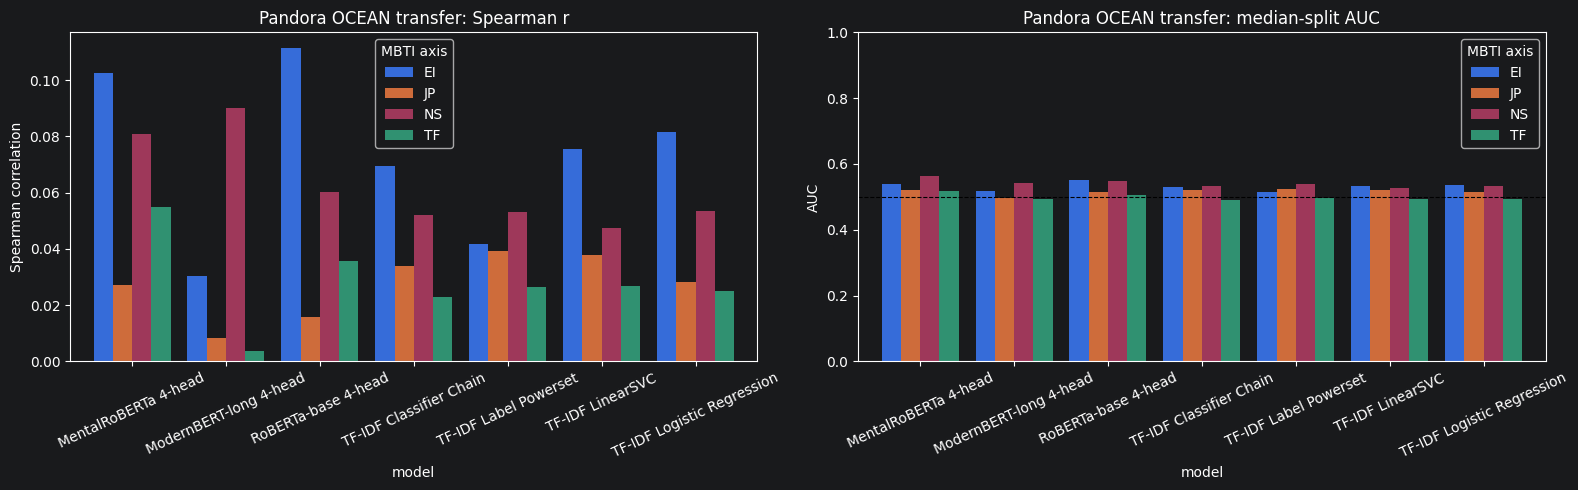


Saved final-model Pandora transfer summary to results\pandora_eval_final_ocean_transfer_summary.csv
Saved final-model Pandora axis probabilities to results\pandora_eval_final_mbti_axis_probs.csv
Saved final-model Pandora transfer plot to results\pandora_eval_final_ocean_transfer.png


In [38]:
def safe_auc_from_continuous_trait(trait_values, scores):
    trait_values = np.asarray(trait_values, dtype=float)
    scores = np.asarray(scores, dtype=float)
    mask = np.isfinite(trait_values) & np.isfinite(scores)
    trait_values = trait_values[mask]
    scores = scores[mask]
    # Median split turns continuous OCEAN scores into a simple high/low diagnostic AUC.
    threshold = np.nanmedian(trait_values)
    labels = (trait_values >= threshold).astype(int)
    if len(np.unique(labels)) < 2:
        return float("nan"), float(threshold)
    return float(roc_auc_score(labels, scores)), float(threshold)


def corr_pair(scores, trait_values, method: Literal["pearson", "kendall", "spearman"]) -> float:
    scores = np.asarray(scores, dtype=float)
    trait_values = np.asarray(trait_values, dtype=float)
    mask = np.isfinite(scores) & np.isfinite(trait_values)
    if mask.sum() < 3:
        return float("nan")
    return float(pd.Series(scores[mask]).corr(pd.Series(trait_values[mask]), method=method))


if PANDORA_PROBS_PATH.exists() and not PANDORA_FORCE_RECOMPUTE:
    print(f"Loading cached final-model Pandora MBTI probabilities from {PANDORA_PROBS_PATH}")
    pandora_pred_df = pd.read_csv(PANDORA_PROBS_PATH)
else:
    print(f"Loading Pandora {PANDORA_SPLIT} split from {PANDORA_PATH}")
    pandora_pred_df = load_pandora_split_final(PANDORA_PATH)

add_tfidf_pandora_predictions(pandora_pred_df)
add_shared_transformer_pandora_predictions(pandora_pred_df)
pandora_pred_df.to_csv(PANDORA_PROBS_PATH, index=False)
print(f"Saved/updated final-model Pandora MBTI probabilities to {PANDORA_PROBS_PATH}")

available_model_keys = []
for model_key in [*PANDORA_TFIDF_MODELS.keys(), *PANDORA_SHARED_TRANSFORMER_CONFIGS.keys()]:
    if all(f"{model_key}_{axis}_prob" in pandora_pred_df.columns for axis in LABEL_ORDER):
        available_model_keys.append(model_key)

summary_rows = []
# Evaluate only model/axis probability columns that were actually produced or cached.
for model_key in available_model_keys:
    display_name = PANDORA_TFIDF_MODELS.get(model_key, PANDORA_SHARED_TRANSFORMER_CONFIGS.get(model_key, {}).get("display", model_key))
    for axis, cfg in OCEAN_TRANSFER_MAP.items():
        trait = str(cfg["trait"])
        score_transform = cast(Callable[[np.ndarray], np.ndarray], cfg["score_transform"])
        score_name = str(cfg["score_name"])
        raw_prob = pandora_pred_df[f"{model_key}_{axis}_prob"].to_numpy(dtype=float)
        score = np.asarray(score_transform(raw_prob), dtype=float)
        trait_values = pandora_pred_df[trait].to_numpy(dtype=float)
        auc, median_threshold = safe_auc_from_continuous_trait(trait_values, score)
        summary_rows.append({
            "model_key": model_key,
            "model": display_name,
            "axis": axis,
            "score": score_name,
            "ocean_trait": trait,
            "pearson_r": corr_pair(score, trait_values, "pearson"),
            "spearman_r": corr_pair(score, trait_values, "spearman"),
            "median_split_auc": auc,
            "trait_median_threshold": median_threshold,
        })

pandora_transfer_df = pd.DataFrame(summary_rows)
pandora_transfer_df.to_csv(PANDORA_SUMMARY_PATH, index=False)

print("\n--- Pandora OCEAN transfer from final MBTI models ---")
print(
    pandora_transfer_df[["model", "axis", "score", "ocean_trait", "pearson_r", "spearman_r", "median_split_auc"]]
    .sort_values(["axis", "spearman_r"], ascending=[True, False])
    .round(4)
)

print("\n--- Best final MBTI model per expected MBTI/OCEAN link by Spearman ---")
best_transfer_rows = (
    pandora_transfer_df
    .sort_values(["axis", "spearman_r"], ascending=[True, False])
    .groupby("axis", as_index=False)
    .head(1)
)
print(best_transfer_rows[["model", "axis", "score", "ocean_trait", "pearson_r", "spearman_r", "median_split_auc"]].round(4))

# Exploratory all-pairs correlations for the strongest expected-link model per axis.
# Use the same psychologically directed score as the expected link, e.g. TF uses P(F), not raw P(T).
all_pair_rows = []
for _, best_row in best_transfer_rows.iterrows():
    model_key = str(best_row["model_key"])
    display_name = str(best_row["model"])
    axis = str(best_row["axis"])
    axis_cfg = OCEAN_TRANSFER_MAP[axis]
    score_transform = cast(Callable[[np.ndarray], np.ndarray], axis_cfg["score_transform"])
    score_name = str(axis_cfg["score_name"])
    raw_score = pandora_pred_df[f"{model_key}_{axis}_prob"].to_numpy(dtype=float)
    directed_score = np.asarray(score_transform(raw_score), dtype=float)
    for trait in OCEAN_TRAITS:
        trait_values = pandora_pred_df[trait].to_numpy(dtype=float)
        all_pair_rows.append({
            "model": display_name,
            "axis": axis,
            "score": score_name,
            "ocean_trait": trait,
            "pearson_r": corr_pair(directed_score, trait_values, "pearson"),
            "spearman_r": corr_pair(directed_score, trait_values, "spearman"),
        })

pandora_all_pairs_df = pd.DataFrame(all_pair_rows)
pandora_all_pairs_df.to_csv(PANDORA_ALL_PAIRS_PATH, index=False)

print("\n--- Exploratory all MBTI-axis/OCEAN Spearman correlations, best final model per axis ---")
print(
    pandora_all_pairs_df
    .pivot_table(index="axis", columns="ocean_trait", values="spearman_r")
    .round(4)
)

# Plot expected OCEAN-link transfer strength.
if not pandora_transfer_df.empty:
    spearman_pivot = pandora_transfer_df.pivot_table(index="model", columns="axis", values="spearman_r")
    auc_pivot = pandora_transfer_df.pivot_table(index="model", columns="axis", values="median_split_auc")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    spearman_pivot.plot(kind="bar", ax=axes[0], width=0.82)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Pandora OCEAN transfer: Spearman r")
    axes[0].set_ylabel("Spearman correlation")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].legend(title="MBTI axis")
    auc_pivot.plot(kind="bar", ax=axes[1], width=0.82)
    axes[1].axhline(0.5, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Pandora OCEAN transfer: median-split AUC")
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].legend(title="MBTI axis")
    plt.tight_layout()
    plt.savefig(PANDORA_TRANSFER_PLOT_PATH, dpi=150)
    plt.show()

print(f"\nSaved final-model Pandora transfer summary to {PANDORA_SUMMARY_PATH}")
print(f"Saved final-model Pandora axis probabilities to {PANDORA_PROBS_PATH}")
print(f"Saved final-model Pandora transfer plot to {PANDORA_TRANSFER_PLOT_PATH}")